In [55]:
# Notwendige Importe

import numpy as np
import pandas as pd
#import plotly.express as px
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, accuracy_score, classification_report, confusion_matrix, normalized_mutual_info_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import pprint
import matplotlib as mpl
import matplotlib.lines as mlines
from scipy.spatial import ConvexHull
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from scipy.spatial.distance import jensenshannon

np.random.seed(42)

In [2]:
#Layout für Grafiken

MAP_FIGSIZE = (6.3, 5.5)
MAP_DPI = 300

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

gdf_bg = gpd.read_file(r"C:\Users\Wunde\Downloads\bundeslaender.geojson.json")

def setup_map_figure(title, figsize = MAP_FIGSIZE):
    fig, ax = plt.subplots(figsize = figsize)
    
    gdf_bg.plot(
        ax = ax,
        color = "#f0f0f0",
        edgecolor = "black",
        linewidth = 0.8,
        zorder = 0
    )
    
    ax.set_title(title, pad = 10, weight = "bold")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    
    return fig, ax

def style_legend(legend):
    if legend is not None:    
        legend.get_frame().set_facecolor("white")
        legend.get_frame().set_edgecolor("black")
        legend.get_frame().set_linewidth(0.6)
        
def add_info_box(ax, text, loc = "bottom_left"):
    
    positions = {
        "bottom_left": (0.02, 0.02, "left", "bottom"),
        "top_left": (0.02, 0.98, "left", "top"),
        "bottom_right": (0.98, 0.02, "right", "bottom"),
        "top_right": (0.98, 0.98, "right", "top"),
    }
    
    x, y, ha, va = positions[loc]
    
    ax.text(
        x, y, text,
        transform = ax.transAxes,
        fontsize = 9,
        horizontalalignment = ha,
        verticalalignment = va, 
        bbox = dict(
            facecolor = "white",
            edgecolor = "black", 
            boxstyle = "round, pad = 0.4",
            linewidth = 0.8
        )
    )
    
def save_map(fig, filename):
    
    fig.tight_layout()
    fig.savefig(filename, dpi = MAP_DPI, bbox_inches = "tight")

In [3]:
#Kapitel 4.1

#Für Reproduzierbarkeit
np.random.seed(42)

# Nachnamen definieren (häufigste Berufsnamen nach Nübling 2015, 154)
names = [
    "Müller", "Schmidt", "Schneider", "Fischer", "Meyer",
    "Weber", "Schulz", "Wagner", "Becker", "Zimmermann", 
    "Schäfer", "Koch", "Schröder", "Richter", "Bauer" 
]

names2 = [
    "Hoffmann", "Krüger", "Keller", "Winkler", "Köhler",
    "Baumann", "Schuhmacher", "Schuster", "Jäger", "Kaufmann",
    "Schreiber", "Bergmann", "Krämer", "Ziegler", "Maurer"
]

# Regionen 
regions = [
    "Nord", "Rheinland", "Bayern",
    "West", "Schwaben", "Ost"    
]

# Städte
cities ={
"Nord": [
    ("Hannover",52.37,9.72),
    ("Braunschweig",52.27,10.52),
    ("Bremen",53.08,8.80),
    ("Hamburg",53.55,10.00),
    ("Kiel",54.32,10.14),
    ("Lübeck",53.87,10.69),
    ("Rostock",54.09,12.14),
    ("Schwerin",53.63,11.41)    
], 
    
"Ost":[
    ("Potsdam",52.39,13.06),
    ("Frankfurt (Oder)",52.35,14.55),
    ("Dresden",51.05,13.74),
    ("Leipzig",51.34,12.37),
    ("Magdeburg",52.13,11.63),
    ("Halle (Saale)",51.48,11.97),
    ("Erfurt",50.98,11.03),
    ("Berlin",52.52,13.40)
],  
    
"West":[
    ("Köln",50.94,6.96),
    ("Münster", 51.96,7.63),
    ("Bonn",50.74,7.10),
    ("Gelsenkirchen",51.52,7.09),
    ("Frankfurt (Main)",50.11,8.68),
    ("Wiesbaden",50.08,8.24),
    ("Kassel",51.31,9.49),
    ("Marburg",50.81,8.77)
], 
    
"Rheinland":[
    ("Koblenz",50.36,7.60),
    ("Mainz",49.99,8.27),
    ("Trier",49.75,6.64),
    ("Cochem",50.15,7.17),
    ("Saarbrücken",49.23,7.00),
    ("Saarlouis",49.31,6.75),
    ("Weiskirchen",49.55,6.82),
    ("St. Ingbert",49.28,7.11)
],
    
"Bayern":[
    ("München",48.13,11.58),
    ("Nürnberg",49.45,11.08),
    ("Würzburg",49.79,9.95),
    ("Passau",48.57,13.46),
    ("Augsburg",48.37,10.90),
    ("Regensburg",49.02,12.10),
    ("Ingolstadt",48.76,11.42),
    ("Füssen",47.57,10.70),
],
    
"Schwaben":[
    ("Heidelberg",49.41,8.69),
    ("Mannheim",49.49,8.47),
    ("Stuttgart",48.78,9.18),
    ("Freiburg",47.99,7.85),
    ("Heilbronn",49.14,9.22),
    ("Tübingen",48.52,9.06),
    ("Konstanz",47.66,9.17),
    ("Ulm",48.40,10.00)
]
}

#Bundeslandzuweisungen
city_to_state = {
    "Hamburg": "Hamburg",
    "Kiel": "Schleswig-Holstein",
    "Lübeck": "Schleswig-Holstein",
    "Bremen": "Bremen",
    "Hannover": "Niedersachsen",
    "Braunschweig": "Niedersachsen",
    "Rostock": "Mecklenburg-Vorpommern",
    "Berlin": "Berlin",
    "Potsdam": "Brandenburg",
    "Frankfurt (Oder)": "Brandenburg",
    "Dresden": "Sachsen", 
    "Leipzig": "Sachsen",
    "Magdeburg": "Sachsen-Anhalt",
    "Halle (Saale)": "Sachsen-Anhalt",
    "Erfurt": "Thüringen",
    "Köln": "Nordrhein-Westfalen",
    "Münster": "Nordrhein-Westfalen", 
    "Bonn": "Nordrhein-Westfalen",
    "Gelsenkirchen": "Nordrhein-Westfalen",
    "Frankfurt (Main)": "Hessen",
    "Wiesbaden": "Hessen", 
    "Kassel": "Hessen",
    "Marburg": "Hessen",
    "Mainz": "Rheinland-Pfalz",
    "Trier": "Rheinland-Pfalz",
    "Koblenz": "Rheinland-Pfalz",
    "Cochem": "Rheinland-Pfalz",
    "Saarbrücken": "Saarland",
    "Saarlouis": "Saarland",
    "Weiskirchen": "Saarland",
    "St. Ingbert": "Saarland", 
    "München": "Bayern",
    "Nürnberg": "Bayern", 
    "Würzburg": "Bayern",
    "Passau": "Bayern",
    "Augsburg": "Bayern",
    "Regensburg": "Bayern",
    "Ingolstadt": "Bayern",
    "Füssen": "Bayern",
    "Stuttgart": "Baden-Württemberg",
    "Heidelberg": "Baden-Württemberg",
    "Mannheim": "Baden-Württemberg", 
    "Freiburg": "Baden-Württemberg", 
    "Heilbronn": "Baden-Württemberg",
    "Tübingen": "Baden-Württemberg", 
    "Konstanz": "Baden-Württemberg",
    "Ulm": "Baden-Württemberg"
}
K = len(names)

#Dataframe erzeugen 
rows = []
for region,city_list in cities.items():
    for city,lat,lon in city_list:
        rows.append({
            "Region": region,
            "Ort": city,
            "lat": lat,
            "lon": lon
        })
        
df_locations = pd.DataFrame(rows)
df_locations["Bundesland"] = df_locations["Ort"].map(city_to_state)

# Nun Einwohnerzahl anhand lognormal-Verteilung generieren
df_locations["Einwohner"] = np.random.lognormal(
    mean = 9,
    sigma = 0.5,
    size = len(df_locations)
).astype(int)
df_locations["Einwohner"] = df_locations["Einwohner"].clip(5000,15000)

# Alpha-Werte für Makroregionen bestimmen 
alpha_base = np.ones(K)
region_alphas = {}
def build_region_alphas(names, dominance = 5.0, moderate = 3.0):
    freq = np.array([
        256003,
        190854,
        115749,
        97658,
        83586,
        86061,
        73736,
        79732,
        74009,
        42872,
        61591,
        59927,
        50648,
        59950,
        58903
    ])
    alpha_base = freq / freq.max()
    alpha_national = alpha_base * 50 
    
    region_alphas = {}
    
    
    for r in regions:
        alpha = alpha_national.copy()
        if r == "Nord":
            alpha[names.index("Schröder")] *= dominance
            alpha[names.index("Schmidt")] *= moderate
            
        elif r == "Bayern":
            alpha[names.index("Bauer")] *= dominance
            alpha[names.index("Meyer")] *= moderate
            
        elif r == "Ost":
            alpha[names.index("Richter")] *= dominance
            alpha[names.index("Schulz")] *= moderate
            
        elif r == "Rheinland":
            alpha[names.index("Becker")] *= dominance
            alpha[names.index("Schäfer")] *= moderate
            
        elif r == "Schwaben":
            alpha[names.index("Zimmermann")] *= dominance
            alpha[names.index("Becker")] *= moderate
            
        elif r == "West":
            alpha[names.index("Schneider")] *= dominance
            alpha[names.index("Weber")] *= moderate   
        region_alphas[r] = alpha 
    return region_alphas
region_alphas = build_region_alphas(names)

#Simulation der Mikroliste
beta = 50
rows = []
for i,row in df_locations.iterrows():
    
    region = row["Region"]
    city = row["Ort"]
    state = row["Bundesland"]
    pop = row["Einwohner"]
    theta_regions = {
        r: np.random.dirichlet(region_alphas[r])
        for r in regions
    } 
    theta_region = theta_regions[region]
    theta_city = np.random.dirichlet(beta * theta_region)
    persons = np.random.choice(
        names,
        size = pop,
        p = theta_city
    )
    for name in persons:
        rows.append([
            region,
            city,
            state,
            row["lat"],
            row["lon"],
            name
        ])
df_micro =pd.DataFrame(
    rows,
    columns = ["Region", "Ort", "Bundesland", "lat", "lon", "Nachname"]
)
print("Simulierte Personen:", len(df_micro))
print(df_micro.head())

Simulierte Personen: 388570
  Region       Ort     Bundesland    lat   lon   Nachname
0   Nord  Hannover  Niedersachsen  52.37  9.72     Müller
1   Nord  Hannover  Niedersachsen  52.37  9.72       Koch
2   Nord  Hannover  Niedersachsen  52.37  9.72  Schneider
3   Nord  Hannover  Niedersachsen  52.37  9.72    Schmidt
4   Nord  Hannover  Niedersachsen  52.37  9.72      Weber


In [4]:
# Ein Teil der Funktion zur Grid-Bestimmung der idealen Alpha-Parameter

def simulate_data(region_alphas, beta = 50):
    
    rows = []
    
    theta_regions = {
        r: np.random.dirichlet(region_alphas[r])
        for r in regions
    } 
    
    for i,row in df_locations.iterrows():
    
        region = row["Region"]
        pop = row["Einwohner"]
        state = row["Bundesland"]
        
        theta_region = theta_regions[region]
    
        #theta_region = np.random.dirichlet(region_alphas[region])
    
        theta_city = np.random.dirichlet(beta * theta_region)
        
        counts = np.random.multinomial(pop,theta_city)
        
        for name, count in zip(names, counts):
            
            for _ in range(count):
                
                rows.append([
                    region,
                    state,
                    row["Ort"],
                    name
                ])
                
    df_micro = pd.DataFrame(
        rows, 
        columns =["Region", "Bundesland", "Ort", "Nachname"]
    )
    
    return df_micro

In [5]:
def build_feature_matrix(df_micro):
    
    counts = pd.crosstab(
        df_micro["Ort"],
        df_micro["Nachname"]
    )
    
    rel = counts.div(counts.sum(axis = 1), axis = 0)
    
    return rel

In [6]:
def compute_score(df_micro, df_rel):
    
    y_true = df_locations.set_index("Ort").loc[df_rel.index]["Region"]
    
    kmeans = KMeans(
        n_clusters = 6,
        n_init = 50, 
        random_state = 42
    )
    
    clusters = kmeans.fit_predict(df_rel)
    
    ari = adjusted_rand_score(y_true, clusters)
    
    score = ari
    
    bayern = df_micro[df_micro.Region == "Bayern"]
    rest = df_micro[df_micro.Region != "Bayern"]
    
    p1 = (bayern.Nachname == "Bauer").mean()
    p2 = (rest.Nachname == "Bauer").mean()
    
    score += (p1 - p2)
    
    return score, ari 

In [14]:
#Ausgabe der idealen Parameter für dominante Namen 

best_score = -999
best_params = None
best_ari = None

for dominance in range(2,6):
    
    for moderate in range(1,4):
        
        scores = []
        aris = []
        
        for _ in range(5):
        
            region_alphas = build_region_alphas(
                names,
                dominance,
                moderate
            )

            df_micro = simulate_data(region_alphas)

            df_rel = build_feature_matrix(df_micro)

            score, ari = compute_score(df_micro, df_rel)

            scores.append(score)
            aris.append(ari)
            
        score = np.mean(scores)
        ari = np.mean(aris)
        
        if score > best_score:
            best_score = score
            best_params = (dominance, moderate)
            best_ari = ari
            
print("Beste Parameter:", best_params)
print ("Ari:", best_ari)

Beste Parameter: (5, 3)
Ari: 0.9286357734896841


In [15]:
pprint.pp(region_alphas)

{'Nord': array([ 50.        , 111.82720515,  22.60696164,  19.07360461,
        16.32519931,  16.80859209,  14.40139373,  15.57247376,
        14.45471342,   8.37333937,  12.02935122,  11.70435503,
        49.46035789,  11.70884716,  11.50435737]),
 'Rheinland': array([50.        , 37.27573505, 22.60696164, 19.07360461, 16.32519931,
       16.80859209, 14.40139373, 15.57247376, 72.27356711,  8.37333937,
       36.08805366, 11.70435503,  9.89207158, 11.70884716, 11.50435737]),
 'Bayern': array([50.        , 37.27573505, 22.60696164, 19.07360461, 48.97559794,
       16.80859209, 14.40139373, 15.57247376, 14.45471342,  8.37333937,
       12.02935122, 11.70435503,  9.89207158, 11.70884716, 57.52178685]),
 'West': array([ 50.        ,  37.27573505, 113.03480819,  19.07360461,
        16.32519931,  50.42577626,  14.40139373,  15.57247376,
        14.45471342,   8.37333937,  12.02935122,  11.70435503,
         9.89207158,  11.70884716,  11.50435737]),
 'Schwaben': array([50.        , 37.27573

In [7]:
#Aggregation zu einer Makroliste auf Ortsebene

df_agg = (
df_micro
.groupby(["Ort", "Nachname"])
.size()
.unstack(fill_value = 0)
)

print(df_agg.head(16))

Nachname          Bauer  Becker  Fischer  Koch  Meyer  Müller  Richter  \
Ort                                                                      
Augsburg           1392     467      533   628   1250     830      169   
Berlin              115     292      364    30    873     568     1127   
Bonn                136     353       85   199    497     466      118   
Braunschweig        387     177      489    33    243     923      121   
Bremen              165     108      806   318    134    1941      242   
Cochem              211    1743      162    25    507    1425       25   
Dresden              62      94      178   463    612     555      425   
Erfurt              191     223      426   121    169     554      803   
Frankfurt (Main)    694     726      473   278    459    1309      266   
Frankfurt (Oder)    595     409      758   462     35    1452     2706   
Freiburg             49    1136      301    84    409     643      673   
Füssen             1786     326      2

In [8]:
#Absolute Zahlen pro Bundesland

df_state_counts = (
    df_micro
    .groupby(["Bundesland", "Nachname"])
    .size()
    .unstack(fill_value = 0)
)

print(df_state_counts)

Nachname                Bauer  Becker  Fischer  Koch  Meyer  Müller  Richter  \
Bundesland                                                                     
Baden-Württemberg        2214    8998     4030  1409   3249    6175     2507   
Bayern                   8150    3351     2222  2231   9333    6253     1362   
Berlin                    115     292      364    30    873     568     1127   
Brandenburg               759     441      839   513    361    2872     4088   
Bremen                    165     108      806   318    134    1941      242   
Hamburg                   624     594      694   203   1659    2244      574   
Hessen                   1351    1185     1618   742    924    3054      990   
Mecklenburg-Vorpommern    178     874      613   129    127    3701       92   
Niedersachsen             789     585      757   681   1217    1919      334   
Nordrhein-Westfalen       899     713     1405   580    859    2795      599   
Rheinland-Pfalz           683    6102   

In [9]:
#Absolute Zahlen pro Bundesland

df_region_counts = (
    df_micro
    .groupby(["Region", "Nachname"])
    .size()
    .unstack(fill_value = 0)
    )

print(df_region_counts)

Nachname   Bauer  Becker  Fischer  Koch  Meyer  Müller  Richter  Schmidt  \
Region                                                                     
Bayern      8150    3351     2222  2231   9333    6253     1362     4929   
Nord        3478    3071     3881  2134   4688   14479     2017    21535   
Ost         1698    2275     2526  1705   2806    6816     9577     5798   
Rheinland   1805   15222     2027  2135   2504    9437     1183     5074   
Schwaben    2214    8998     4030  1409   3249    6175     2507     8159   
West        2250    1898     3023  1322   1783    5849     1589     6023   

Nachname   Schneider  Schröder  Schulz  Schäfer  Wagner  Weber  Zimmermann  
Region                                                                      
Bayern          4848      1243    1785     3623    4519   3516         844  
Nord            4903      9595    2196     3488    3785   4167        2039  
Ost             2818      1779    7323     1660    1805   4671        1886  
Rheinl

In [10]:
# Relative Wahrscheinlichkeiten 

df_rel = df_agg.div(df_agg.sum(axis=1), axis = 0)
print(df_rel.head())

Nachname         Bauer    Becker   Fischer      Koch     Meyer    Müller  \
Ort                                                                        
Augsburg      0.154753  0.051918  0.059255  0.069817  0.138966  0.092273   
Berlin        0.018800  0.047736  0.059506  0.004904  0.142717  0.092856   
Bonn          0.026428  0.068597  0.016518  0.038671  0.096580  0.090556   
Braunschweig  0.051184  0.023410  0.064674  0.004365  0.032139  0.122074   
Bremen        0.014731  0.009642  0.071958  0.028390  0.011963  0.173288   

Nachname       Richter   Schmidt  Schneider  Schröder    Schulz   Schäfer  \
Ort                                                                         
Augsburg      0.018788  0.046137   0.029127  0.032018  0.076376  0.019011   
Berlin        0.184241  0.112800   0.089259  0.000817  0.159555  0.032205   
Bonn          0.022930  0.092888   0.234551  0.007967  0.005441  0.024485   
Braunschweig  0.016003  0.286735   0.140458  0.032271  0.003042  0.033461   
Breme

In [11]:
#relative Wahrscheinlichkeiten für Bundesländer

df_state_rel = df_state_counts.div(
    df_state_counts.sum(axis = 1),
    axis = 0
)

df_state_rel = df_state_rel.sort_index()

print(df_state_rel)

Nachname                   Bauer    Becker   Fischer      Koch     Meyer  \
Bundesland                                                                 
Baden-Württemberg       0.033544  0.136329  0.061059  0.021348  0.049226   
Bayern                  0.140013  0.057568  0.038173  0.038327  0.160336   
Berlin                  0.018800  0.047736  0.059506  0.004904  0.142717   
Brandenburg             0.044555  0.025888  0.049252  0.030114  0.021192   
Bremen                  0.014731  0.009642  0.071958  0.028390  0.011963   
Hamburg                 0.041600  0.039600  0.046267  0.013533  0.110600   
Hessen                  0.037929  0.033269  0.045425  0.020832  0.025941   
Mecklenburg-Vorpommern  0.011867  0.058267  0.040867  0.008600  0.008467   
Niedersachsen           0.043960  0.032594  0.042177  0.037943  0.067807   
Nordrhein-Westfalen     0.036505  0.028952  0.057051  0.023551  0.034880   
Rheinland-Pfalz         0.023142  0.206749  0.037440  0.023040  0.047740   
Saarland    

In [12]:
#Relative Wahrscheinlichkeit für Makroregion

df_region_rel = df_region_counts.div(
    df_region_counts.sum(axis = 1),
    axis = 0)

print(df_region_rel)

Nachname      Bauer    Becker   Fischer      Koch     Meyer    Müller  \
Region                                                                  
Bayern     0.140013  0.057568  0.038173  0.038327  0.160336  0.107423   
Nord       0.040699  0.035937  0.045415  0.024972  0.054859  0.169432   
Ost        0.030793  0.041256  0.045808  0.030920  0.050886  0.123606   
Rheinland  0.028419  0.239664  0.031914  0.033615  0.039424  0.148581   
Schwaben   0.033544  0.136329  0.061059  0.021348  0.049226  0.093558   
West       0.037347  0.031504  0.050178  0.021943  0.029595  0.097085   

Nachname    Richter   Schmidt  Schneider  Schröder    Schulz   Schäfer  \
Region                                                                   
Bayern     0.023398  0.084678   0.083286  0.021354  0.030665  0.062241   
Nord       0.023603  0.252001   0.057375  0.112280  0.025697  0.040816   
Ost        0.173676  0.105145   0.051103  0.032262  0.132800  0.030104   
Rheinland  0.018626  0.079888   0.043046  0.0

In [13]:
#Dominante Rel. Namen pro Bundesland

df_dominant = df_state_rel.idxmax(axis = 1). reset_index()

df_dominant.columns = ["Bundesland", "Dominanter Nachname"]

print(df_dominant)

                Bundesland Dominanter Nachname
0        Baden-Württemberg          Zimmermann
1                   Bayern               Meyer
2                   Berlin             Richter
3              Brandenburg             Richter
4                   Bremen             Schmidt
5                  Hamburg             Schmidt
6                   Hessen           Schneider
7   Mecklenburg-Vorpommern              Müller
8            Niedersachsen             Schmidt
9      Nordrhein-Westfalen           Schneider
10         Rheinland-Pfalz              Becker
11                Saarland              Becker
12                 Sachsen             Schmidt
13          Sachsen-Anhalt               Weber
14      Schleswig-Holstein             Schmidt
15               Thüringen             Schmidt


C:\Users\Wunde\AppData\Local\Temp\ipykernel_2684\2435237302.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1")


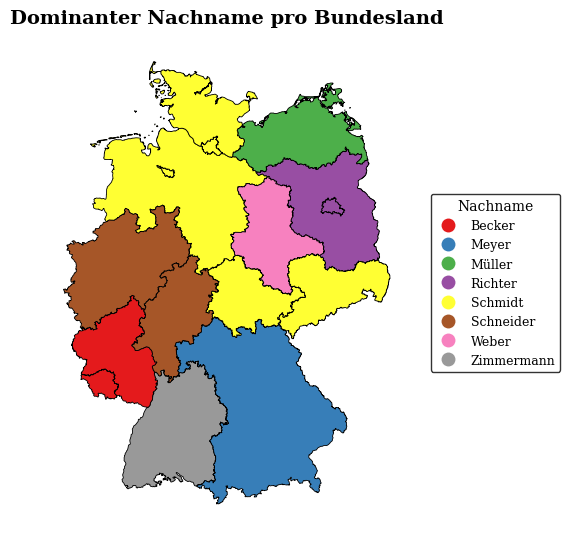

In [16]:
# Kaptiel 6.1
#dominanter Nachname pro Bundesland

#with open(r"C:\Users\Wunde\Downloads\bundeslaender.geojson.json", "r", encoding = "utf-8") as f:
#    geojson_data = json.load(f)

gdf = gpd.read_file(r"C:\Users\Wunde\Downloads\bundeslaender.geojson.json")

gdf = gdf.merge(
    df_dominant,
    left_on = "name",
    right_on = "Bundesland"
)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.fontsize": 9
})

fig, ax = plt.subplots(figsize = (6.3, 5.5))

cmap = plt.cm.get_cmap("Set1")
unique_vals = gdf["Dominanter Nachname"].unique()

gdf.plot(
    column = "Dominanter Nachname",
    ax = ax,
    legend = True,
    cmap = cmap,
    edgecolor = "black",
    linewidth = 0.6
)

ax.set_title("Dominanter Nachname pro Bundesland",
            pad = 12,
            weight = "bold"
)

ax.set_axis_off()

legend = ax.get_legend()
if legend:
    legend.set_title("Nachname")
    legend.get_title().set_fontsize(10)
    legend.set_loc("center left")
    
    legend.set_bbox_to_anchor((1.05, 0.5))
    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_edgecolor("black")
    legend.set_frame_on(True)

plt.tight_layout()

plt.savefig(
    "karte_nachnamen1.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

In [17]:
#Kap. 6.2
# JS-Divergenz

def kl_divergence(p,q):
    
    epsilon = 1e-12
    
    p = np.clip(p,epsilon,1)
    q = np.clip(q,epsilon,1)
    
    return np.sum(p * np.log(p/q))

def js_divergence(p,q):
    
    m = 0.5 * (p+q)
    
    return 0.5 * kl_divergence(p,m) + 0.5 * kl_divergence(q,m)

In [18]:
def compute_region_js_matrix(df_rel, regions):
    
    region_means = (
        df_rel
        .assign(Region = df_rel.index.str.split("_").str[0])
        .groupby("Region")
        .mean()
    )
    
    region_names = region_means.index
    n = len(region_names)
    
    js_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            js_matrix[i, j] = js_divergence(
                region_means.iloc[i].values,
                region_means.iloc[j].values
            )
            
    return js_matrix, region_names

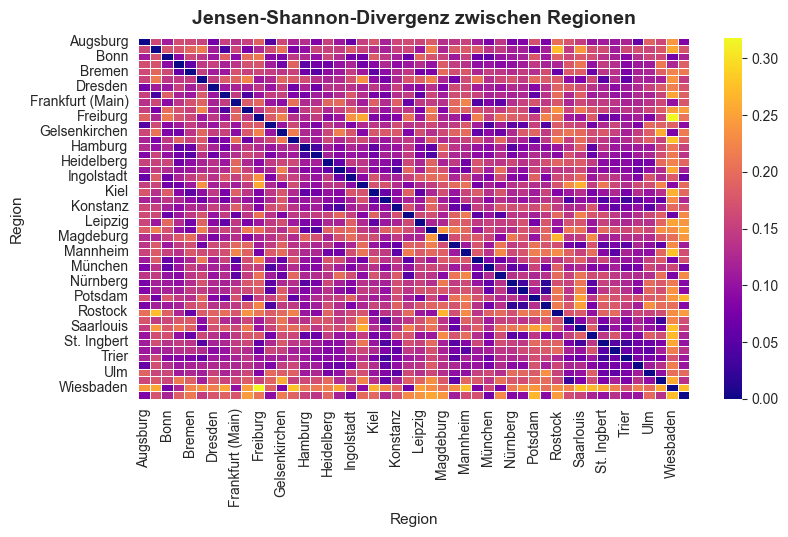

In [19]:
#JS-Matrix auf Ortsebene

js_matrix, region_names = compute_region_js_matrix(df_rel, regions)

df_js = pd.DataFrame(
    js_matrix,
    index = region_names,
    columns = region_names
)

sns.set_style("white")

fix, ax = plt.subplots(figsize = (8.5, 5.5))

sns.heatmap(
    df_js,
    annot = False,
    fmt = ".3f",
    cmap = "plasma",
    linewidth = 0.5,
    linecolor = "white",
    ax = ax
)

ax.set_title("Jensen-Shannon-Divergenz zwischen Regionen", pad = 10, weight = "bold")
plt.xlabel("Region")
plt.ylabel("Region")

plt.tight_layout()
plt.savefig("kap6_js_divergenz_matrix.png", dpi = 300, bbox_inches = "tight")
plt.show()

Fehlende Orte im Index: []
Fehlende Orte in den Spalten: []
       Ort1          Ort2        JS Region1 Region2
0  Augsburg      Augsburg  0.000000  Bayern  Bayern
1  Augsburg        Berlin  0.161090  Bayern     Ost
2  Augsburg          Bonn  0.111331  Bayern    West
3  Augsburg  Braunschweig  0.166514  Bayern    Nord
4  Augsburg        Bremen  0.162199  Bayern    Nord

Aggregierte Regionenmatrix:
Region2     Nord  Rheinland  Bayern   West  Schwaben    Ost
Region1                                                    
Nord       0.077      0.147   0.137  0.148     0.128  0.140
Rheinland  0.157      0.065   0.137  0.201     0.103  0.162
Bayern     0.140      0.149   0.067  0.151     0.144  0.149
West       0.156      0.168   0.139  0.075     0.159  0.160
Schwaben   0.160      0.118   0.158  0.201     0.078  0.142
Ost        0.157      0.158   0.160  0.168     0.144  0.085


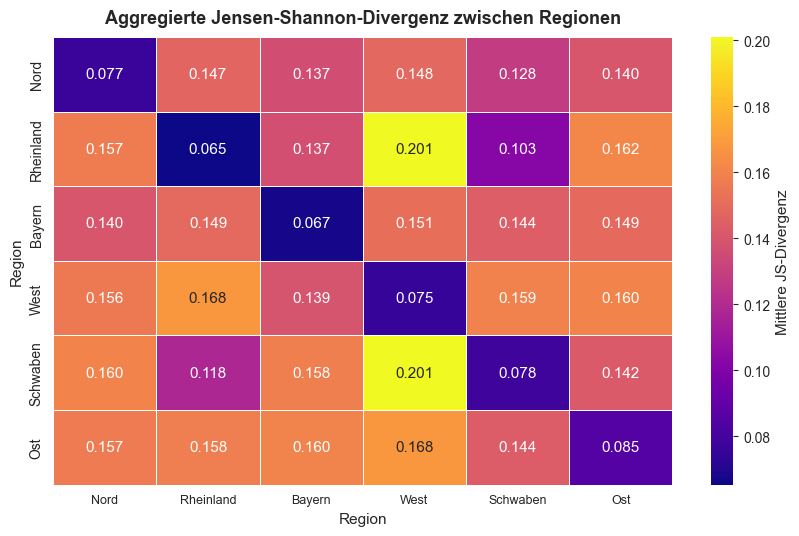

In [29]:
#Aggregation zu Regionen
city_to_region = (
    df_locations[["Ort", "Region"]]
    .drop_duplicates()
    .set_index("Ort")["Region"]
    .to_dict()
)
missing_index = [city for city in df_js.index if city not in city_to_region]
missing_cols = [city for city in df_js.columns if city not in city_to_region]
print("Fehlende Orte im Index:", missing_index)
print("Fehlende Orte in den Spalten:", missing_cols)
df_js.index.name = None
df_js.columns.name = None
df_long = df_js.stack().reset_index()
df_long.columns = ["Ort1", "Ort2", "JS"]
df_long["Region1"] = df_long["Ort1"].map(city_to_region)
df_long["Region2"] = df_long["Ort2"].map(city_to_region)
print(df_long.head())
df_long["pair_key"] = df_long.apply(
    lambda row: tuple(sorted([row["Ort1"], row["Ort2"]])),
    axis = 1
)
df_long_unique = df_long.drop_duplicates(subset = "pair_key").copy()
df_long_unique = df_long_unique[df_long_unique["Ort1"] != df_long_unique["Ort2"]].copy()
region_matrix = (
    df_long_unique
    .groupby(["Region1", "Region2"])["JS"]
    .mean()
    .unstack()
)
#Reihenfolge
region_order = ["Nord", "Rheinland", "Bayern", "West", "Schwaben", "Ost"]
region_matrix = region_matrix.loc[region_order, region_order]
print("\nAggregierte Regionenmatrix:")
print(region_matrix.round(3))
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 10
})
sns.set_style("white")
fig, ax = plt.subplots(figsize = (8.5, 5.5)) # für 2,5cm-Rand
sns.heatmap(
    region_matrix,
    annot = True,
    fmt = ".3f",
    cmap = "plasma",
    linewidths = 0.5,
    linecolor = "white",
    cbar_kws ={"label": "Mittlere JS-Divergenz"},
    ax = ax
)
#Beschriftung
ax.set_title("Aggregierte Jensen-Shannon-Divergenz zwischen Regionen", pad = 10, weight = "bold")
plt.xlabel("Region")
plt.ylabel("Region")
plt.tight_layout()
#Speichern
plt.savefig("kap6_js_divergenz_regionen_aggregiert.png", dpi = 300, bbox_inches = "tight")
plt.show()                  
                   


In [83]:
# Kapitel 4.2, 5.1
#MC

def run_simulation(beta, seed):
    np.random.seed(seed)
    region_alphas = build_region_alphas(names)
    rows = []
    for r in regions:
        theta_region = np.random.dirichlet(region_alphas[r])
        # Orte der Region aus df_locations holen
        region_locs = df_locations[df_locations["Region"] == r]
        for _, row in region_locs.iterrows():
            location = row["Ort"]
            n_location = row["Einwohner"]
            theta_location = np.random.dirichlet (beta * theta_region)
            persons = np.random.choice(
                names,
                size = n_location,
                p = theta_location
            )
            for name in persons:
                rows.append([r, location, name])
    df_micro = pd.DataFrame(rows, columns = ["Region", "Ort", "Nachname"])
    df_agg = (
        df_micro
        .groupby(["Ort","Nachname"])
        .size()
        .unstack(fill_value = 0)
    )
    df_rel = df_agg.div(df_agg.sum(axis = 1), axis = 0)
    #Cluster für Qualität
    kmeans = KMeans(n_clusters = 6, n_init = 50, random_state = seed)
    clusters = kmeans.fit_predict(df_rel)
    sil = silhouette_score(df_rel, clusters)
    #JS
    js_matrix, _ = compute_region_js_matrix(df_rel, regions)
    mean_js = js_matrix[np.triu_indices(len(js_matrix), 1)].mean()
    return sil, mean_js
#Variation von Beta
betas = [20, 50, 100]
results = []
for beta in betas: 
    sil_scores = []
    js_scores = []
    #Für Reproduktivität
    for seed in range(50):
        sil, js = run_simulation(beta, seed)
        sil_scores.append(sil)
        js_scores.append(js)
    #Alles ins Dataframe    
    results.append({
        "beta": beta,
        "mean_silhouette": np.mean(sil_scores),
        "std_silhouette": np.std(sil_scores),
        "mean_js_divergence": np.mean(js_scores),
        "std_js_divergence": np.std(js_scores)
    }) 
results_df = pd.DataFrame(results)
print(results_df.round(3))

   beta  mean_silhouette  std_silhouette  mean_js_divergence  \
0    20            0.200           0.027               0.204   
1    50            0.322           0.031               0.136   
2   100            0.456           0.031               0.108   

   std_js_divergence  
0              0.009  
1              0.008  
2              0.007  


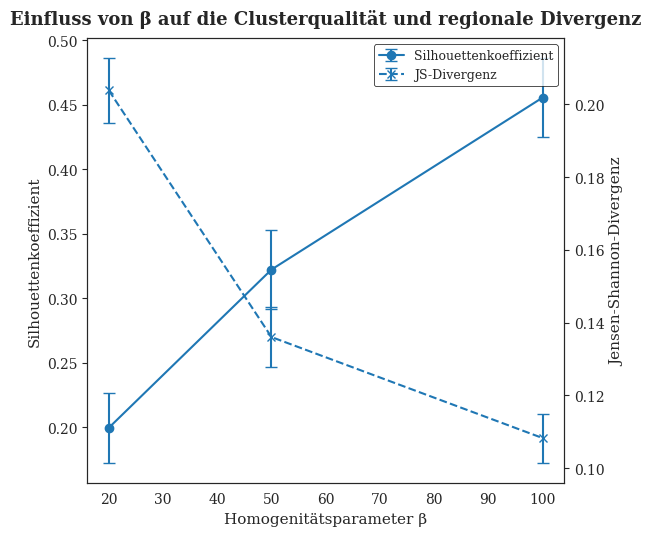

In [107]:
#Visualisierung 5.1

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
#    "legend.fontsize": 9
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, ax1 = plt.subplots(figsize = (6.3, 5.5))

ax1.errorbar(
    results_df["beta"],
    results_df["mean_silhouette"],
    yerr = results_df["std_silhouette"],
    marker = "o",
    capsize = 4,
    linewidth = 1.5,
    label = "Silhouettenkoeffizient"
)

ax1.set_xlabel("Homogenitätsparameter β")
ax1.set_ylabel("Silhouettenkoeffizient")

ax2 = ax1.twinx()

ax2.errorbar(
    results_df["beta"],
    results_df["mean_js_divergence"],
    yerr = results_df["std_js_divergence"],
    marker = "x",
    linestyle = "--",
    capsize = 4,
    linewidth = 1.5,
    label = "JS-Divergenz"
)

ax2.set_ylabel("Jensen-Shannon-Divergenz")

ax1.set_title(
    "Einfluss von β auf die Clusterqualität und regionale Divergenz",
    pad = 10, 
    weight = "bold"
)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

legend = ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc = "upper right",
    frameon = True
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(0.6)

plt.tight_layout()

plt.savefig(
    "kap5_beta_combined.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

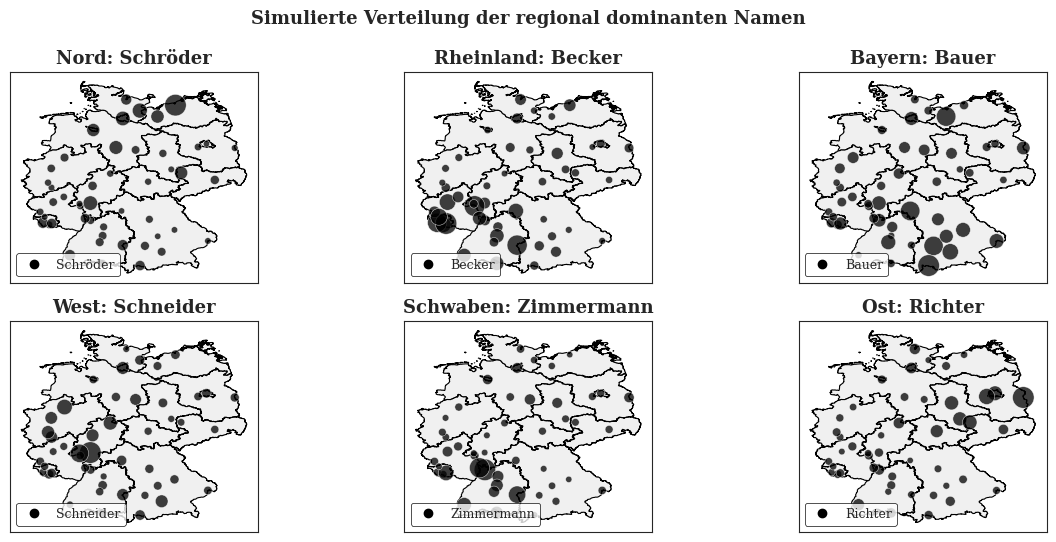

In [49]:
#Visualisierung 6.1

gdf_bg = gpd.read_file(r"C:\Users\Wunde\Downloads\bundeslaender.geojson.json")

dominant_names = {
    "Nord": "Schröder",
    "Bayern": "Bauer",
    "Ost": "Richter",
    "Rheinland": "Becker",
    "Schwaben": "Zimmermann",
    "West": "Schneider"
    
}

region_order = ["Nord", "Rheinland", "Bayern", "West", "Schwaben", "Ost"]

fig, axes = plt.subplots(2, 3, figsize =(12.6, 5.5))
axes = axes.flatten()

for ax, region in zip (axes, region_order):
    
    surname = dominant_names[region]
    
    gdf_bg.plot(
        ax = ax, 
        color = "#f0f0f0",
        edgecolor = "black",
        linewidth = 0.8,
        zorder = 0
    )
    
    df_plot = (
        df_micro[df_micro["Nachname"] == surname]
        .groupby(["Ort", "lat", "lon"])
        .size()
        .reset_index(name = "count")
    )
    
    if not df_plot.empty:
        df_plot["rel"] = df_plot["count"] / df_plot["count"].max()
    else:
        df_plot["rel"] = 0.0
        
    ax.scatter(
        df_plot["lon"],
        df_plot["lat"],
        s = 220 * df_plot["rel"] + 20,
        color = "black",
        alpha = 0.75,
        edgecolor = "white",
        linewidth = 0.4,
        zorder = 2
    )
    
    ax.set_title(f"{region}: {surname}", pad = 6, weight = "bold")
    
    handle = mlines.Line2D(
        [], [],
        marker = 'o',
        color = "white",
        markerfacecolor = "black",
        markeredgecolor = "black",
        markersize = 6,
        linestyle = 'None',
        label = surname
    )
    
    legend = ax.legend(
        handles = [handle],
        loc = "lower left",
        frameon = True
    )
    
    style_legend(legend)
    
    total_count = int((df_micro["Nachname"] == surname).sum())

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    

fig.suptitle(
    "Simulierte Verteilung der regional dominanten Namen",
    fontsize = 13,
    fontweight = "bold",
    y = 0.98
)

plt.tight_layout()

plt.savefig(
    "kap6_dominante_namen_modelliert.png",
    dpi = MAP_DPI,
    bbox_inches = "tight"
)

plt.show()

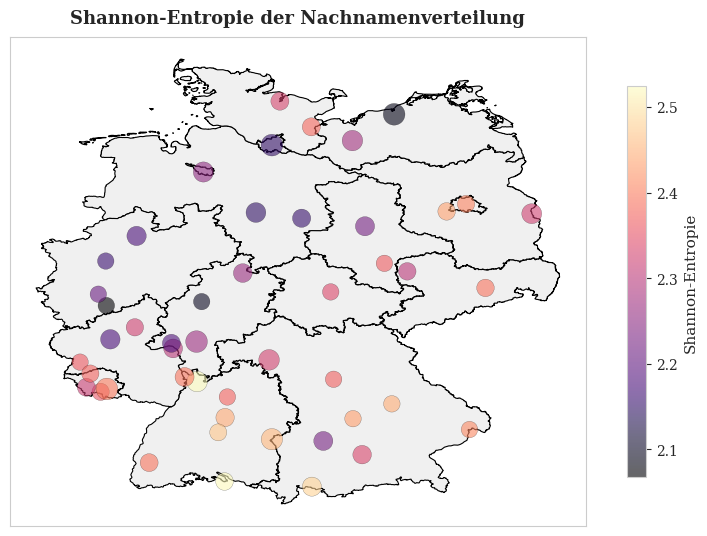

In [66]:
#Shannon-Entropie
#Wurde aus Arbeit genommen aufgrund der Zeichenzahl

def shannon_entropy(p):
    epsilon = 1e-12
    p = np.clip(p, epsilon, 1)
    return -np.sum(p * np.log(p))
entropy_values = []
for ort in df_rel.index: 
    p = df_rel.loc[ort].values
    H = shannon_entropy(p)
    entropy_values.append(H)   
df_entropy = pd.DataFrame({
    "Ort": df_rel.index,
    "Entropy": entropy_values
})
df_entropy["Ort"] = df_entropy["Ort"].map(str)
df_map = df_entropy.merge(
    df_locations,
    on = "Ort",
    how = "left"
)
#Deutschlandkarte laden
gdf_bg = gpd.read_file(r"C:\Users\Wunde\Downloads\bundeslaender.geojson.json")
#Parameter für Beschriftung
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
#    "axes.labelsize": 11,
#    "legend.fontsize": 9
})
#Größe des Plots
fix, ax = plt.subplots(figsize = (8.5, 5.5))
gdf_bg.plot(
    ax = ax,
    color = "#f0f0f0",
    edgecolor = "black",
    linewidth = 0.8,
    zorder = 0
)
#Punkte auf Karte
sc= ax.scatter(
        df_map["lon"], 
        df_map["lat"],
        s = np.sqrt(df_map["Einwohner"]) * 2,
        c = df_map["Entropy"],
        edgecolor = "black",
        cmap = "magma",
        linewidth = 0.2,
        alpha = 0.6,
        zorder = 2,
)    
cbar = plt.colorbar(sc, ax = ax, shrink = 0.8)
cbar.set_label("Shannon-Entropie")
#Beschriftung
ax.set_title("Shannon-Entropie der Nachnamenverteilung", pad = 10, weight = "bold")
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")
plt.tight_layout()
#Speichern
plt.savefig("kap6_entropy_karte.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [67]:
print(df_map)

                 Ort   Entropy     Region    lat    lon  \
0           Augsburg  2.224264     Bayern  48.37  10.90   
1             Berlin  2.406420        Ost  52.52  13.40   
2               Bonn  2.067505       West  50.74   7.10   
3       Braunschweig  2.154860       Nord  52.27  10.52   
4             Bremen  2.252662       Nord  53.08   8.80   
5             Cochem  2.174540  Rheinland  50.15   7.17   
6            Dresden  2.389035        Ost  51.05  13.74   
7             Erfurt  2.337631        Ost  50.98  11.03   
8   Frankfurt (Main)  2.268084       West  50.11   8.68   
9   Frankfurt (Oder)  2.322141        Ost  52.35  14.55   
10          Freiburg  2.392457   Schwaben  47.99   7.85   
11            Füssen  2.483377     Bayern  47.57  10.70   
12     Gelsenkirchen  2.160332       West  51.52   7.09   
13     Halle (Saale)  2.364584        Ost  51.48  11.97   
14           Hamburg  2.150543       Nord  53.55  10.00   
15          Hannover  2.148577       Nord  52.37   9.72 

In [34]:
#Grid Search der idealen Parameter für DBSCAN

gdf = gpd.read_file(r"C:\Users\Wunde\Downloads\bundeslaender.geojson.json")

df_full = df_locations.merge(
    df_rel,
    on = "Ort"
)

name_features = [col for col in df_rel.columns if col != "Ort"]

X_names = df_full[name_features].values
X_geo = df_full[["lat", "lon"]].values 

#geo_X = df_locations[["lat", "lon"]].values

X_names_scaled = StandardScaler().fit_transform(X_names)

pca = PCA(n_components = 5)
X_names_reduced = pca.fit_transform(X_names_scaled)

X_geo_scaled = StandardScaler().fit_transform(X_geo)

alpha = 0.7 
beta = 0.3

X_combined = np. hstack([
    alpha * X_names_reduced,
    beta * X_geo_scaled
])

y_true = df_full["Region"].values

# Grid-Search

eps_values = np.arange(1.0, 2.1, 0.1)
min_samples_values = [3, 4, 5, 6, 7, 8]

target_clusters = 6
results = []

for eps in eps_values:
    for min_s in min_samples_values:
        
        db = DBSCAN(eps = eps, min_samples = min_s)
        labels = db.fit_predict(X_combined)
        
        mask = labels != -1
        noise_ratio = np.mean(labels == -1)
        noise_count = int(np.sum(labels == -1))
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if np.sum(mask) < 2 or len(set(labels[mask])) < 2:
            ari = np.nan
            nmi = np.nan
            score = -999
        else:
            ari = adjusted_rand_score(y_true[mask], labels[mask])
            nmi = normalized_mutual_info_score(y_true[mask], labels [mask])
            
            cluster_penalty = abs(n_clusters - target_clusters)
            score = ari - 0.15 * cluster_penalty - 0.50 * noise_ratio
        
        results.append({
            "eps": round(float(eps), 3),
            "min_samples": int(min_s),
            "ARI": ari, 
            "NMI": nmi,
            "n_clusters": int(n_clusters), 
            "noise_ratio": float(noise_ratio),
            "noise_count": int(noise_count),
            "score": score
        })
        
df_grid = pd.DataFrame(results)

df_grid_valid = df_grid[df_grid["score"] > -999].copy()

if df_grid_valid.empty:
    raise ValueError(
    "Keine gültige Kombination gefunden. "
    )

best_row = df_grid_valid.sort_values(
    by = ["score", "ARI", "NMI"],
    ascending = False
).iloc[0]

best_eps = best_row["eps"]
best_min_samples = int(best_row["min_samples"])

print("Beste Parameter:", best_row)

Beste Parameter: eps            1.400000
min_samples    3.000000
ARI            0.841931
NMI            0.924116
n_clusters     6.000000
noise_ratio    0.125000
noise_count    6.000000
score          0.779431
Name: 24, dtype: float64


In [35]:
db_best = DBSCAN(eps = best_eps, min_samples = best_min_samples)
best_labels = db_best.fit_predict(X_combined)

df_full["Cluster"] = best_labels
df_locations["Cluster"] = best_labels
        
best_mask = best_labels != -1
best_noise_ratio = np.mean(best_labels == -1)
best_noise_count = int(np.sum(best_labels == -1))
best_n_clusters = len(set(best_labels)) - (1 if -1 in best_labels else 0)
        
if np.sum(best_mask) < 2 or len(set(best_labels[best_mask])) < 2:
    best_ari = np.nan
    best_nmi = np.nan
else:
    best_ari = adjusted_rand_score(y_true[best_mask], best_labels[best_mask])
    best_nmi = normalized_mutual_info_score(y_true[best_mask], best_labels [best_mask])
            
print("\nMetriken der besten Variante:")
print(f"ARI = {best_ari: .3f}" if pd.notna(best_ari) else "ARI = nan")
print(f"NMI = {best_nmi: .3f}" if pd.notna(best_nmi) else "NMI = nan")
print(f"Clusterzahl = {best_n_clusters}")
print(f"Noise = {best_noise_count} / {len(df_locations)} {best_noise_ratio: .1%}")


Metriken der besten Variante:
ARI =  0.842
NMI =  0.924
Clusterzahl = 6
Noise = 6 / 48  12.5%


In [36]:
db = DBSCAN(eps = best_eps, min_samples = best_min_samples)
clusters = db.fit_predict(X_combined)

df_full["Cluster"] = clusters
df_locations["Cluster"] = clusters

print("\nCluster-Verteilung:")
print(df_full["Cluster"].value_counts())


Cluster-Verteilung:
Cluster
 3    11
 1     8
 2     7
 4     7
-1     6
 0     5
 5     4
Name: count, dtype: int64


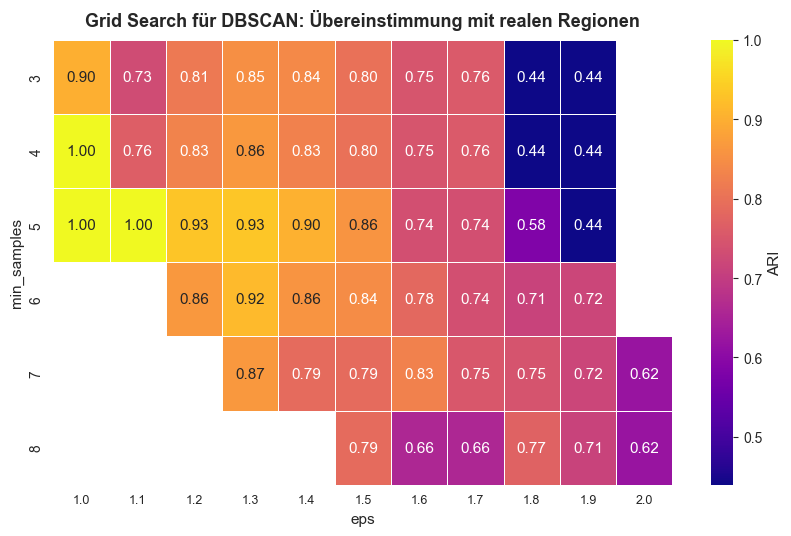

<Figure size 640x480 with 0 Axes>

In [37]:
#Visualisierung der Grid Search 

heatmap_data = df_grid.pivot(
    index = "min_samples",
    columns = "eps",
    values = "ARI"
)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 10
})

sns.set_style("white")

fix, ax = plt.subplots(figsize = (8.5, 5.5))

sns.heatmap(
    heatmap_data,
    annot = True,
    fmt = ".2f",
    cmap = "plasma",
    linewidths = 0.5,
    linecolor = "white",
    cbar_kws = {"label": "ARI"},
    ax = ax
)

plt.title("Grid Search für DBSCAN: Übereinstimmung mit realen Regionen", pad = 10, weight = "bold")
plt.xlabel("eps")
plt.ylabel("min_samples")

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.savefig("DBSCAN_gridsearch_ari.png", dpi = 300, bbox_inches = "tight")
plt.show()

C:\Users\Wunde\AppData\Local\Temp\ipykernel_7092\264685112.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1", len(clusters_unique_no_noise))


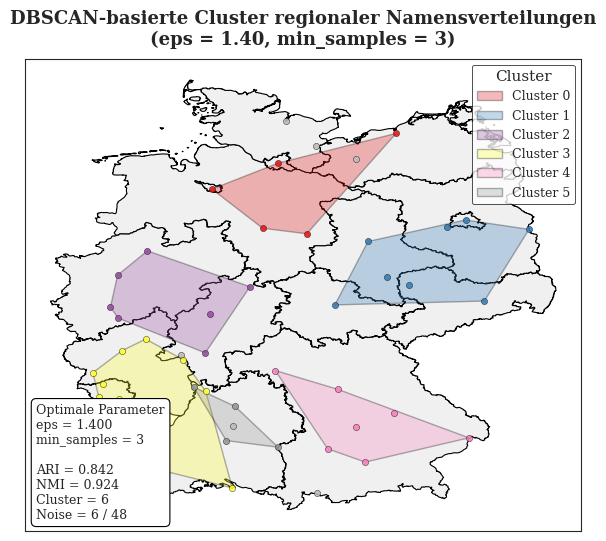

Cluster
 3    11
 1     8
 2     7
 4     7
-1     6
 0     5
 5     4
Name: count, dtype: int64


In [38]:
#DBSCAN Cluster-Erkennung und Plot

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
#    "axes.titlesize": 14,
#    "axes.labelsize": 11,
#    "legend.fontsize": 9
})

fig, ax = plt.subplots(figsize = (6.3, 5.5))

gdf.plot(
    ax = ax,
    color = "#f0f0f0",
    edgecolor = "black",
    linewidth = 0.8,
    zorder = 1
)

clusters_unique = sorted(df_locations["Cluster"].unique())
clusters_unique_no_noise = [c for c in clusters_unique if c != -1]

if len(clusters_unique_no_noise) > 0:
    cmap = plt.cm.get_cmap("Set1", len(clusters_unique_no_noise))
    cluster_colors = {cl: cmap(i) for i, cl in enumerate(clusters_unique_no_noise)}
else:
    cluster_colors = {}
    
cluster_colors[-1] = "#bbbbbb"




for cl in clusters_unique_no_noise:
    subset = df_locations[df_locations["Cluster"] == cl]
    
    if len(subset) < 3:
        continue
        
    points = subset[["lon", "lat"]].values
    
    try: 
        hull = ConvexHull(points)
        hull_points = points[hull.vertices]
        
        ax.fill(
            hull_points[:, 0],
            hull_points[:, 1],
            color = cluster_colors[cl],
            edgecolor = "black",
            linewidth = 1,
            alpha = 0.3,
            label = f"Cluster {cl}",
            zorder = 2
        )
    except:
        pass
    
    
for cl in df_locations["Cluster"].unique():
    subset = df_locations[df_locations["Cluster"] == cl]
    
    ax.scatter(
        subset["lon"], 
        subset["lat"],
        s = 20,
        color = cluster_colors.get(cl, "#bbbbbb"),
        edgecolor = "black",
        linewidth = 0.3,
        alpha = 0.9,
        zorder = 3, 
    )

ax.set_title(
    f"DBSCAN-basierte Cluster regionaler Namensverteilungen\n"
    f"(eps = {best_eps:.2f}, min_samples = {best_min_samples})",
             pad = 10,
             weight = "bold"
)

ax.set_xticks([])
ax.set_yticks([])          
ax.set_aspect('equal')

legend = ax.legend(title = "Cluster", loc = "upper right", frameon = True)
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_facecolor("white")
legend.get_frame().set_linewidth(0.6)

param_text = (
    f"Optimale Parameter\n"
    f"eps = {best_eps:.3f}\n"
    f"min_samples = {best_min_samples}\n\n"
    f"ARI = {best_ari:.3f}\n"
    f"NMI = {best_nmi:.3f}\n"
    f"Cluster = {best_n_clusters}\n"
    f"Noise = {best_noise_count} / {len(df_locations)}"
)

ax.text(
    0.02, 0.02,
    param_text,
    transform = ax.transAxes, 
    fontsize = 9, 
    verticalalignment = "bottom",
    bbox = dict(
        facecolor = "white",
        edgecolor = "black", 
        boxstyle = "round, pad = 0.4",
        linewidth = 0.8
    )
)

plt.tight_layout()
plt.savefig("DBSCAN_cluster_flaechen1.png", dpi = 300, bbox_inches = "tight")
plt.show()

print(df_full["Cluster"].value_counts())

In [39]:
print("\nTop 10 Parameterkombinationen nach ARI:")
print(
    df_grid.sort_values(by = ["ARI", "NMI"], ascending = False)
    .head(25)
    .round(3)
)


Top 10 Parameterkombinationen nach ARI:
    eps  min_samples    ARI    NMI  n_clusters  noise_ratio  noise_count  \
1   1.0            4  1.000  1.000           3        0.646           31   
2   1.0            5  1.000  1.000           3        0.688           33   
8   1.1            5  1.000  1.000           3        0.646           31   
20  1.3            5  0.934  0.959           4        0.438           21   
14  1.2            5  0.932  0.958           4        0.479           23   
21  1.3            6  0.917  0.938           3        0.542           26   
26  1.4            5  0.903  0.955           5        0.292           14   
0   1.0            3  0.900  0.941           5        0.500           24   
22  1.3            7  0.865  0.875           2        0.667           32   
15  1.2            6  0.865  0.873           2        0.688           33   
19  1.3            4  0.865  0.944           5        0.271           13   
27  1.4            6  0.860  0.912           3 

In [41]:
#KMeans-Cluster

kmeans = KMeans(
    n_clusters = 6,
    n_init = 50,
    random_state = 42
)

kmeans_labels = kmeans.fit_predict(df_state_rel)

df_clusters = df_state_rel.copy()
df_clusters["Cluster"] = kmeans_labels

print(df_clusters)

Nachname                   Bauer    Becker   Fischer      Koch     Meyer  \
Bundesland                                                                 
Baden-Württemberg       0.032863  0.102118  0.059029  0.047802  0.083210   
Bayern                  0.177584  0.032435  0.058170  0.033878  0.159580   
Berlin                  0.020925  0.063593  0.023541  0.023868  0.075364   
Brandenburg             0.034224  0.029469  0.079777  0.040857  0.026945   
Bremen                  0.013659  0.041961  0.030087  0.044371  0.037229   
Hamburg                 0.035533  0.015067  0.027600  0.004467  0.024733   
Hessen                  0.016873  0.032202  0.053033  0.038519  0.033971   
Mecklenburg-Vorpommern  0.021800  0.029000  0.023467  0.011733  0.023267   
Niedersachsen           0.032427  0.028694  0.034990  0.008803  0.021562   
Nordrhein-Westfalen     0.021846  0.012019  0.030657  0.027490  0.018273   
Rheinland-Pfalz         0.035780  0.229417  0.055465  0.030799  0.046148   
Saarland    

                      name              Bundesland  Cluster
0        Baden-Württemberg       Baden-Württemberg        2
1                   Bayern                  Bayern        4
2                   Berlin                  Berlin        1
3              Brandenburg             Brandenburg        1
4                   Bremen                  Bremen        0
5                  Hamburg                 Hamburg        0
6                   Hessen                  Hessen        3
7   Mecklenburg-Vorpommern  Mecklenburg-Vorpommern        0
8            Niedersachsen           Niedersachsen        0
9      Nordrhein-Westfalen     Nordrhein-Westfalen        3
10         Rheinland-Pfalz         Rheinland-Pfalz        2
11                Saarland                Saarland        2
12          Sachsen-Anhalt          Sachsen-Anhalt        5
13                 Sachsen                 Sachsen        5
14      Schleswig-Holstein      Schleswig-Holstein        0
15               Thüringen              

C:\Users\Wunde\AppData\Local\Temp\ipykernel_7092\629358163.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1", gdf["Cluster"].nunique())


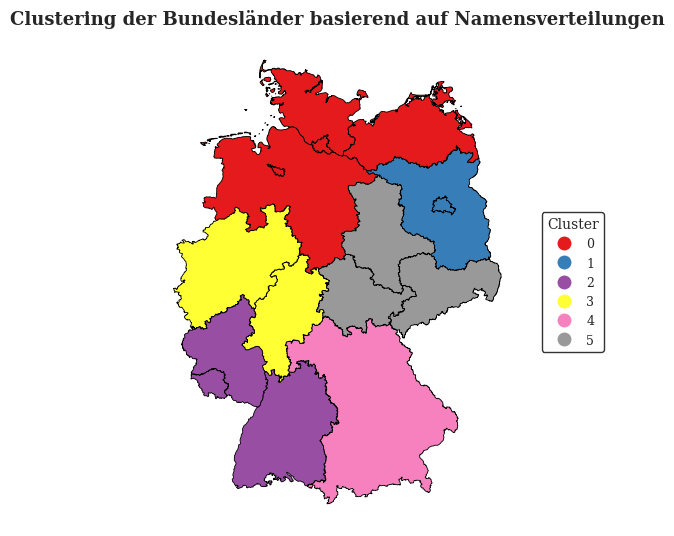

In [42]:
#Clustering auf Bundeslandebene
#Kap 7.1

gdf = gpd.read_file(r"C:\Users\Wunde\Downloads\bundeslaender.geojson.json")

df_clusters = df_clusters.reset_index()

#if "Bundesland" not in df_clusters.columns:
#    df_clusters = df_clusters.rename(columns = {df_clusters.columns[0]: "Bundesland"})

df_clusters = df_clusters[["Bundesland", "Cluster"]]

gdf = gdf.merge(
    df_clusters,
    left_on = "name",
    right_on = "Bundesland",
    how = "left"
)

print(gdf[["name", "Bundesland", "Cluster"]].head(20))
print(gdf["Cluster"].isna().sum(), "NaN-Werte")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
#    "axes.labelsize": 11,
    "legend.fontsize": 9
})

fig, ax = plt.subplots(figsize = (6.3, 5.5))

gdf["Cluster"] = gdf["Cluster"].astype("category")

cmap = plt.cm.get_cmap("Set1", gdf["Cluster"].nunique())

gdf.plot(
    column = "Cluster",
    ax = ax,
    legend = True,
    cmap = cmap,
    edgecolor = "black",
    linewidth = 0.6,
)

ax.set_title("Clustering der Bundesländer basierend auf Namensverteilungen",
            pad = 10,
            weight = "bold"
)

ax.set_axis_off()

legend = ax.get_legend()
if legend:
    legend.set_title("Cluster")
    legend.get_title().set_fontsize(10)
    legend.set_loc("center left")
    
    legend.set_bbox_to_anchor((1.05, 0.5))
    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_edgecolor("black")
    legend.set_frame_on(True)

plt.tight_layout()

plt.savefig(
    "cluster_karte1.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

In [69]:
#KMeans auf Ortsebene
#Kap 7.1

kmeans_loc = KMeans(
    n_clusters = 6,
    n_init = 50,
    random_state = 42
)

kmeans_labels_loc = kmeans_loc.fit_predict(df_rel)

df_clusters_loc = df_rel.copy()
df_clusters_loc["Cluster"] = kmeans_labels_loc

df_clusters_loc = df_clusters_loc.reset_index()

if df_clusters_loc.columns[0] != "Ort":
    df_clusters_loc = df_clusters_loc.rename(columns = {df_clusters_loc.columns[0]: "Ort"})

df_clusters_loc = df_clusters_loc[["Ort", "Cluster"]].copy()

df_clusters_loc.columns.name = None

df_clusters_loc["Ort"] = df_clusters_loc["Ort"].astype(str).str.strip()
df_locations["Ort"] = df_locations["Ort"].astype(str).str.strip()

print("df_clusters_loc:")
print(df_clusters_loc.head())
print("\nSpalten in df_clusters_loc:", df_clusters_loc.columns.tolist())

df_clusters_loc:
            Ort  Cluster
0      Augsburg        3
1        Berlin        1
2          Bonn        2
3  Braunschweig        5
4        Bremen        5

Spalten in df_clusters_loc: ['Ort', 'Cluster']



Merge-Kontrolle:
                Ort Region  Cluster
0          Hannover   Nord        5
1      Braunschweig   Nord        5
2            Bremen   Nord        5
3           Hamburg   Nord        5
4              Kiel   Nord        5
5            Lübeck   Nord        3
6           Rostock   Nord        5
7          Schwerin   Nord        1
8           Potsdam    Ost        1
9  Frankfurt (Oder)    Ost        1
Fehlende Cluster nach Merge: 0


C:\Users\Wunde\AppData\Local\Temp\ipykernel_7092\9474038.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1", len(clusters_no_noise))


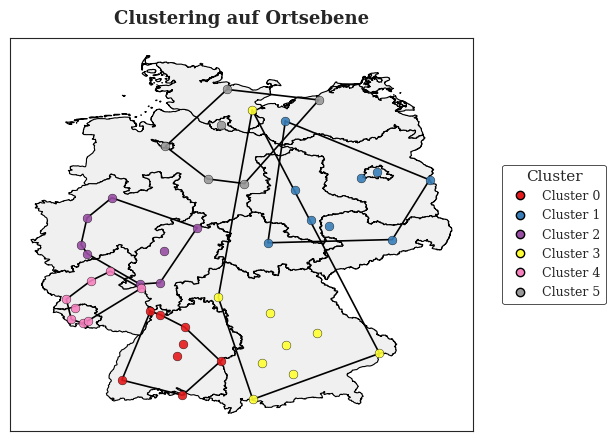

       Region               Ort    lat    lon              Bundesland  \
0        Nord          Hannover  52.37   9.72           Niedersachsen   
1        Nord      Braunschweig  52.27  10.52           Niedersachsen   
2        Nord            Bremen  53.08   8.80                  Bremen   
3        Nord           Hamburg  53.55  10.00                 Hamburg   
4        Nord              Kiel  54.32  10.14      Schleswig-Holstein   
5        Nord            Lübeck  53.87  10.69      Schleswig-Holstein   
6        Nord           Rostock  54.09  12.14  Mecklenburg-Vorpommern   
7        Nord          Schwerin  53.63  11.41                     NaN   
8         Ost           Potsdam  52.39  13.06             Brandenburg   
9         Ost  Frankfurt (Oder)  52.35  14.55             Brandenburg   
10        Ost           Dresden  51.05  13.74                 Sachsen   
11        Ost           Leipzig  51.34  12.37                 Sachsen   
12        Ost         Magdeburg  52.13  11.63      

In [124]:
#Plot auf Ortsebene

gdf = gpd.read_file(r"C:\Users\Wunde\Downloads\bundeslaender.geojson.json")


#if "Bundesland" not in df_clusters.columns:
#    df_clusters = df_clusters.rename(columns = {df_clusters.columns[0]: "Bundesland"})

df_plot = df_locations.merge(
    df_clusters_loc,
    on = "Ort",
    how = "left"
)

print("\nMerge-Kontrolle:")
print(df_plot[["Ort", "Region", "Cluster"]].head(10))
print("Fehlende Cluster nach Merge:", df_plot["Cluster"].isna().sum())

df_plot["Cluster"] = df_plot["Cluster"].fillna(-1).astype(int)

if "Cluster" not in df_plot.columns:
    df_plot["Cluster"] = np.nan

df_plot["Cluster"] = df_plot["Cluster"].fillna(-1).astype(int)

#print(gdf[["Ort", "Region", "Cluster"]].head())

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
#    "axes.labelsize": 11,
    "legend.fontsize": 9
})

fig, ax = plt.subplots(figsize = (6.3, 5.5))

gdf.plot(
    ax = ax,
    color = "#f0f0f0",
    edgecolor = "black",
    linewidth = 0.8,
    zorder = 0
)

unique_clusters = sorted(df_plot["Cluster"].unique())
clusters_no_noise = [c for c in unique_clusters if c != -1]

cmap = plt.cm.get_cmap("Set1", len(clusters_no_noise))
cluster_colors = {cl: cmap(i) for i, cl in enumerate(clusters_no_noise)}
cluster_colors[-1] = "#bbbbbb"


for cl in clusters_no_noise:
    subset = df_plot[df_plot["Cluster"] == cl]
    
    if len(subset) < 3:
        continue
        
    points = subset[["lon", "lat"]].values
     
    hull = ConvexHull(points)
    hull_points = points[hull.vertices]
    
    hull_points = np.vstack([hull_points, hull_points[0]])
        
    ax.plot(
        hull_points[:, 0],
        hull_points[:, 1],
        color = "black",
        linewidth = 1.2,
        zorder = 1
        )

for cl in unique_clusters:
    subset = df_plot[df_plot["Cluster"] == cl]

    ax.scatter(
        subset["lon"],
        subset["lat"],
        color = cluster_colors[cl],
        s = 40,
        edgecolor = "black",
        linewidth = 0.3,
        alpha = 0.9,
        label = f"Cluster {cl}",
        zorder = 2
    )

#gdf.plot(
#    column = "Cluster",
#    ax = ax,
#    legend = True,
#    cmap = cmap,
#    edgecolor = "black",
#    linewidth = 0.6,
#)

ax.set_title("Clustering auf Ortsebene",
            pad = 10,
            weight = "bold"
)

ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

handles = []
labels = []

for cl in sorted(df_plot["Cluster"].dropna().unique()):
    handles.append(
        mlines.Line2D(
            [0], [0],
            marker = 'o',
            color = 'w',
            markerfacecolor = cluster_colors[cl],
            markeredgecolor = 'black',
            markersize = 6,
            linestyle = 'None'
        )
    )
    labels.append(f"Cluster {int(cl)}")

legend = ax.legend(
    handles, 
    labels,
    title = "Cluster",
    loc = "center left",
    bbox_to_anchor = (1.05, 0.5),
    frameon = True
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(0.6)


plt.tight_layout()

plt.savefig(
    "kmeans_orte.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()
print(df_plot)

C:\Users\Wunde\AppData\Local\Temp\ipykernel_7092\1992397272.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_regions = plt.cm.get_cmap("Set1", len(regions_present))


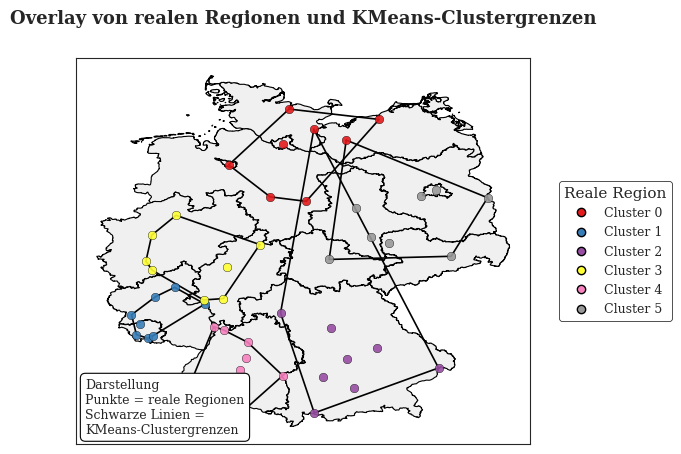

In [125]:
#Veranschaulichung, ob Städte in Clustern liegen
#Kap 7.1

kmeans_overlay = KMeans(
    n_clusters = 6,
    n_init = 50, 
    random_state = 42
)

kmeans_labels_overlay = kmeans_overlay.fit_predict(df_rel)

df_clusters_overlay = df_rel.copy()
df_clusters_overlay["Cluster"] = kmeans_labels_overlay
df_clusters_overlay = df_clusters_overlay.reset_index()

if df_clusters_overlay.columns[0] != "Ort":
    df_clusters_overlay = df_clusters_overlay.rename(columns = {df_clusters_overlay.columns[0]: "Ort"})
    
df_clusters_overlay = df_clusters_overlay[["Ort", "Cluster"]].copy()
df_clusters_overlay.columns.name = None
df_clusters_overlay["Ort"] = df_clusters_overlay["Ort"].astype(str).str.strip()

df_plot = df_locations.merge(
    df_clusters_overlay,
    on = "Ort",
    how = "left"
)

df_plot["Cluster"] = df_plot["Cluster"].fillna(-1).astype(int)

gdf = gpd.read_file(r"C:\Users\Wunde\Downloads\bundeslaender.geojson.json")

region_order = ["Nord", "Rheinland", "Bayern", "West", "Schwaben", "Ost"]

regions_present = [r for r in region_order if r in df_plot["Region"].unique()]
cmap_regions = plt.cm.get_cmap("Set1", len(regions_present))
region_colors = {reg: cmap_regions(i) for i, reg in enumerate (regions_present)}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
#    "axes.labelsize": 11,
    "legend.fontsize": 9,
 #   "xtick.labelsize": 10,
  #  "ytick.labelsize": 10
})

fig, ax = plt.subplots(figsize = (6.3, 5.5))

gdf.plot(
    ax = ax,
    color = "#f0f0f0",
    edgecolor = "black",
    linewidth = 0.8,
    zorder = 0
)

for cl in clusters_no_noise:
    subset = df_plot[df_plot["Cluster"] == cl]
    
    if len(subset) < 3:
        continue
        
    points = subset[["lon", "lat"]].values
     
    try:
        hull = ConvexHull(points)
        hull_points = points[hull.vertices]

        hull_points = np.vstack([hull_points, hull_points[0]])

        ax.plot(
            hull_points[:, 0],
            hull_points[:, 1],
            color = "black",
            linewidth = 1.2,
            zorder = 1
            )
    except:
        pass
    
for reg in regions_present:
    subset = df_plot[df_plot["Region"] == reg]
    
    ax.scatter(
        subset["lon"],
        subset["lat"],
        s = 38,
        color = region_colors[reg],
        edgecolor = "black",
        linewidth = 0.3,
        alpha = 0.9,
        label = reg,
        zorder = 2
    )

ax.set_title(
    f"Overlay von realen Regionen und KMeans-Clustergrenzen\n",
             pad = 10,
             weight = "bold"
)

ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

legend = ax.legend(
    handles, 
    labels,
    title = "Reale Region",
    loc = "center left",
    bbox_to_anchor = (1.05, 0.5),
    frameon = True
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(0.6)

info_text = (
    "Darstellung\n"
    "Punkte = reale Regionen\n"
    "Schwarze Linien =\nKMeans-Clustergrenzen"
)

ax.text(
    0.02, 0.02,
    info_text,
    transform = ax.transAxes, 
    fontsize = 9, 
    verticalalignment = "bottom",
    bbox = dict(
        facecolor = "white",
        edgecolor = "black", 
        boxstyle = "round, pad = 0.4",
        linewidth = 0.8
    )
)

plt.tight_layout()

plt.savefig(
    "kap9_overlay_regionen_kmeans.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

    k  Silhouette
0   2       0.205
1   3       0.223
2   4       0.289
3   5       0.332
4   6       0.344
5   7       0.333
6   8       0.315
7   9       0.301
8  10       0.282


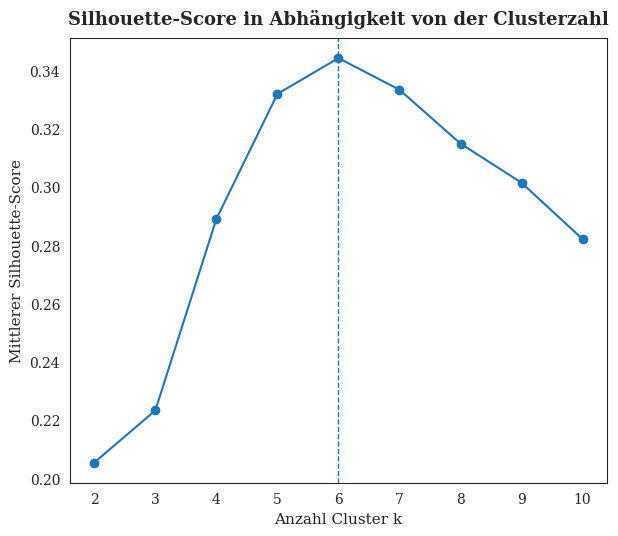

In [126]:
#Kap. 7.2
#Bestimmung der optimalen Clusterzahl

k_values = range(2,11)
sil_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters = k, 
        n_init = 50, 
        random_state = 42
    )
    
    labels = kmeans.fit_predict(df_rel)
    sil = silhouette_score(df_rel, labels)
    sil_scores.append(sil)
    
df_sil = pd.DataFrame({
    "k": list(k_values),
    "Silhouette": sil_scores
})

print(df_sil.round(3))

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
#    "legend.fontsize": 9,
 #   "xtick.labelsize": 10,
  #  "ytick.labelsize": 10
})

fig, ax = plt.subplots(figsize = (6.3, 5.5))

ax.plot(
    df_sil["k"],
    df_sil["Silhouette"], 
    marker = "o",
    linewidth = 1.5
)

best_k = df_sil.loc[df_sil["Silhouette"].idxmax(), "k"]
best_sil = df_sil["Silhouette"].max()

ax.axvline(
    best_k,
    linestyle = "--",
    linewidth = 1
)

ax.set_title("Silhouette-Sore in Abhängigkeit von der Clusterzahl", pad = 10, weight = "bold")
ax.set_xlabel("Anzahl Cluster k")
ax.set_ylabel("Mittlerer Silhouette-Score")

plt.tight_layout()

plt.savefig(
    "kap7_silhouette_linie.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

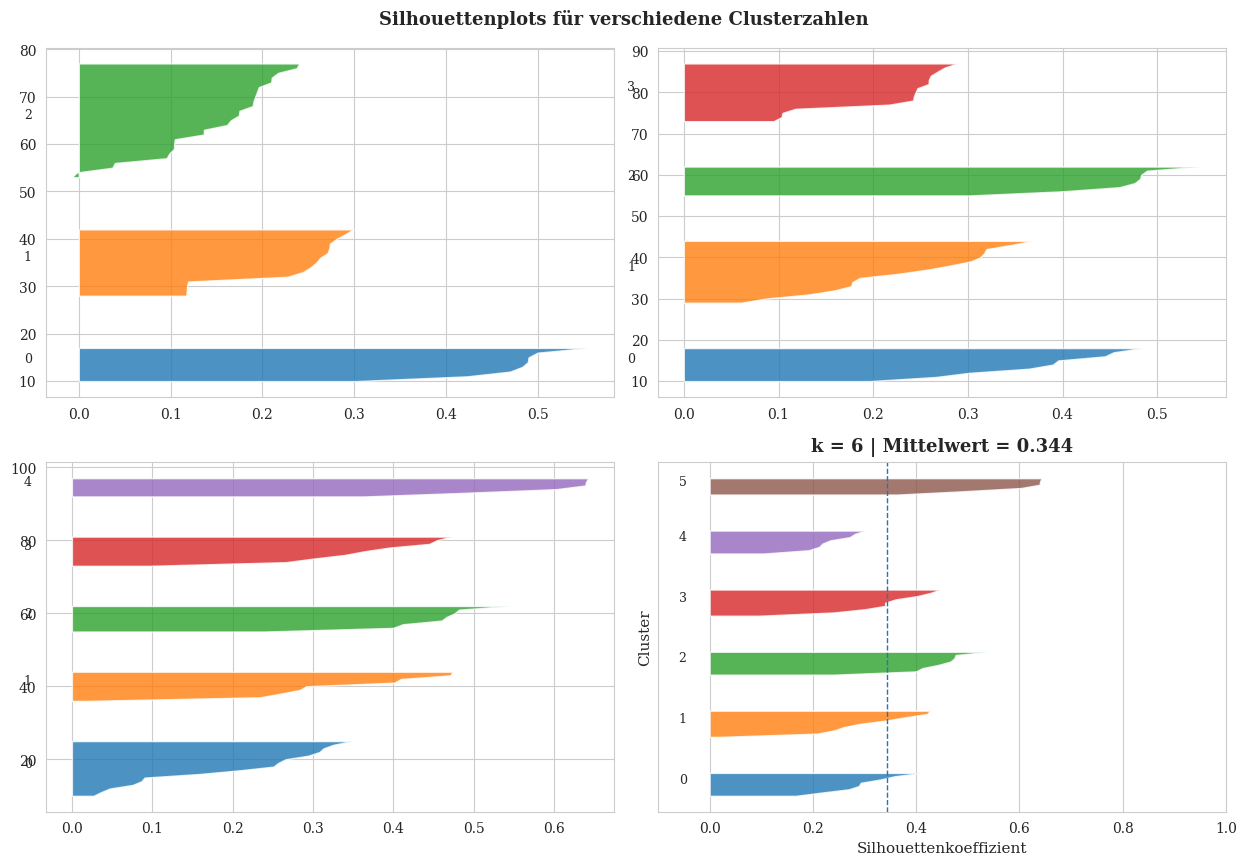

In [62]:
#Alternativer Silhouettenplot

k_values = [3, 4, 5, 6]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
#    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

fig, axes = plt.subplots(2, 2, figsize = (12.6, 8.8))
axes = axes.flatten()

for ax, k in zip(axes, k_values):
    
    kmeans = KMeans(
        n_clusters = k,
        n_init = 50, 
        random_state = 42
    )
    
    cluster_labels = kmeans.fit_predict(df_rel)

    silhouette_avg = silhouette_score(df_rel, cluster_labels)
    sample_silhouette_values = silhouette_samples(df_rel, cluster_labels)

    y_lower = 10

    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            alpha = 0.8
        )

        ax.text(
            -0.06,
            y_lower + 0.5 * size_cluster_i,
            str(i),
            fontsize = 9
        )

        y_lower = y_upper +10
    
ax.axvline(
    x = silhouette_avg,
    linestyle = "--",
    linewidth = 1
)

ax.set_title(f"k = {k} | Mittelwert = {silhouette_avg:.3f}", pad = 8, weight = "bold")
ax.set_xlabel("Silhouettenkoeffizient")
ax.set_ylabel("Cluster")
ax.set_yticks([])
ax.set_xlim([-0.1, 1])

fig.suptitle(
    "Silhouettenplots für verschiedene Clusterzahlen",
    fontsize = 13,
    fontweight = "bold",
    y = 0.98
)

plt.tight_layout()

plt.savefig(
    "kapt7_silhouetteplot_messer.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

In [51]:
kmeans = KMeans(
    n_clusters = 6,
    n_init = 50,
    random_state = 42
)

clusters = kmeans.fit_predict(df_rel)

df_compare = df_rel.reset_index()

if df_compare.columns[0] != "Ort":
    df_compare = df_compare.rename(columns = {df_compare.columns[0]: "Ort"})


df_compare["KMeans_Cluster"] = clusters

df_compare = df_compare.merge(
    df_locations[["Ort", "Region"]].drop_duplicates(),
    on = "Ort",
    how = "left"
)

In [52]:
#Crosstab-Tabelle
#Kap 7.2

ct_abs = pd.crosstab(
    df_compare["Region"],
    df_compare["KMeans_Cluster"],
    margins = True
)

ct_rel = pd.crosstab(
    df_compare["Region"],
    df_compare["KMeans_Cluster"],
    normalize = "index"
)

print(ct_abs.round(2))
print(ct_rel.round(2))

KMeans_Cluster  0  1  2  3  4  5  All
Region                               
Bayern          0  0  0  8  0  0    8
Nord            0  1  0  1  0  6    8
Ost             0  8  0  0  0  0    8
Rheinland       0  0  0  0  8  0    8
Schwaben        8  0  0  0  0  0    8
West            0  0  8  0  0  0    8
All             8  9  8  9  8  6   48
KMeans_Cluster    0     1    2     3    4     5
Region                                         
Bayern          0.0  0.00  0.0  1.00  0.0  0.00
Nord            0.0  0.12  0.0  0.12  0.0  0.75
Ost             0.0  1.00  0.0  0.00  0.0  0.00
Rheinland       0.0  0.00  0.0  0.00  1.0  0.00
Schwaben        1.0  0.00  0.0  0.00  0.0  0.00
West            0.0  0.00  1.0  0.00  0.0  0.00


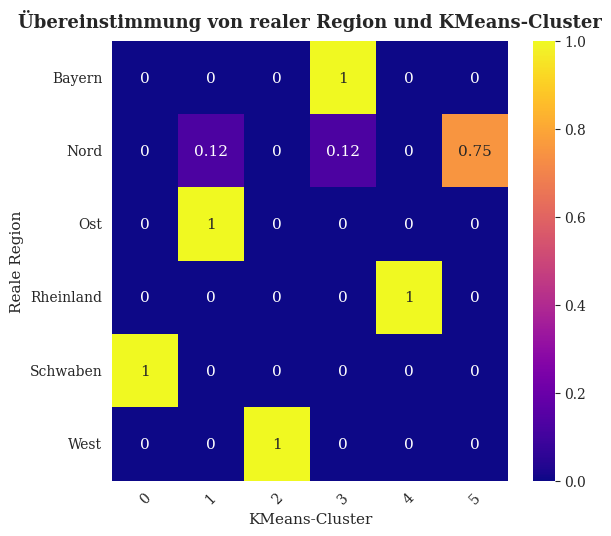

In [122]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
#    "axes.labelsize": 11,
#    "legend.fontsize": 9
})

fig, ax = plt.subplots(figsize = (6.3, 5.5))

sns.heatmap(
    ct_rel,
    annot = True,
    cmap = "plasma",
    ax = ax
)

ax.set_title("Übereinstimmung von realer Region und KMeans-Cluster", pad = 10, weight = "bold")
ax.set_xlabel("KMeans-Cluster")
ax.set_ylabel("Reale Region")
ax.tick_params(axis = "x", rotation = 45)

plt.tight_layout()

plt.savefig(
    "crosstab_region_kmeans.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

In [127]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(
    df_compare["Region"],
    df_compare["KMeans_Cluster"]
)

print(f"Adjusted Rand Index: {ari}")

Adjusted Rand Index: 0.8993278676416279


C:\Users\Wunde\AppData\Local\Temp\ipykernel_2684\2203491964.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1", len(regions))


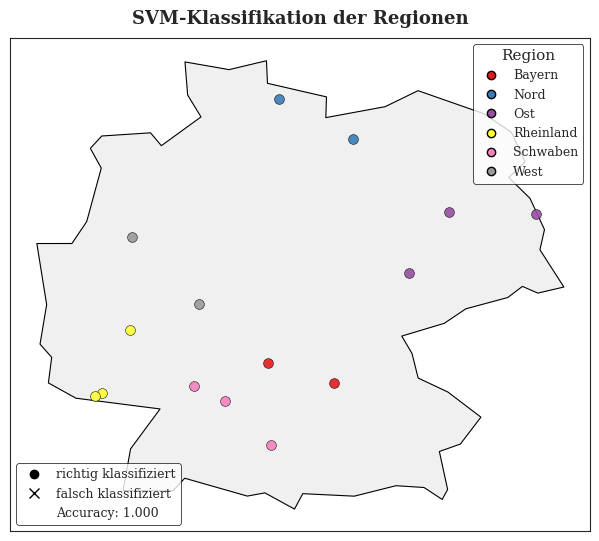

Accuracy: 1.0
Classification Report:               precision    recall  f1-score   support

      Bayern       1.00      1.00      1.00         2
        Nord       1.00      1.00      1.00         2
         Ost       1.00      1.00      1.00         3
   Rheinland       1.00      1.00      1.00         3
    Schwaben       1.00      1.00      1.00         3
        West       1.00      1.00      1.00         2

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

Confusion Matrix: [[2 0 0 0 0 0]
 [0 2 0 0 0 0]
 [0 0 3 0 0 0]
 [0 0 0 3 0 0]
 [0 0 0 0 3 0]
 [0 0 0 0 0 2]]


In [61]:
#Kap.8
#SVM-Klassifikation der Orte

X = df_rel.copy()
y = df_locations.set_index("Ort").loc[df_rel.index]["Region"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)
svm = SVC(
    kernel = "rbf",
    gamma = "scale"
)

svm.fit(X_train, y_train)

pred = svm.predict(X_test)

df_svm = X_test.reset_index()

if df_svm.columns[0] != "Ort":
    df_svm = df_svm.rename(columns = {df_svm.columns[0]: "Ort"})
    
df_svm["PredRegion"] = pred
df_svm["TrueRegion"] = y_test.values
df_svm["Correct"] = df_svm["PredRegion"] == df_svm["TrueRegion"]

df_svm = df_svm.merge(
    df_locations[["Ort", "lat", "lon"]],
    on = "Ort",
    how = "left"
)

world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

germany = world[world["ADMIN"] == "Germany"]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
#    "legend.fontsize": 9
})

fig, ax = plt.subplots(figsize = (6.3, 5.5))

germany.plot(
    ax = ax,
    color = "#f0f0f0",
    edgecolor = "black",
    linewidth = 0.8,
    zorder = 0
)

regions = sorted(df_svm["PredRegion"].unique())
cmap = plt.cm.get_cmap("Set1", len(regions))

color_dict = {region: cmap(i) for i, region in enumerate(regions)}


for region in regions:
    subset = df_svm[df_svm["PredRegion"] == region]
    
    correct = subset[subset["Correct"]]
    wrong = subset[~subset["Correct"]]
    
    #Richtig
    
    ax.scatter(
        correct["lon"],
        correct["lat"],
        s = 50, 
        color = color_dict[region],
        edgecolor = "black",
        linewidth = 0.4,
        marker = "o",
        alpha = 0.9,
        zorder = 2
    )
    
    #Falsch
    
    ax.scatter(
        wrong["lon"],
        wrong["lat"],
        s = 70, 
        color = color_dict[region],
        linewidth = 1.2, 
        marker = "x",
        zorder = 3
    )
    
ax.set_title("SVM-Klassifikation der Regionen", pad = 10, weight = "bold")

ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

region_handles = [
    mlines.Line2D(
        [], [],
        marker = "o",
        color = color_dict[r],
        linestyle = 'None',
        markeredgecolor = 'black',
        markersize = 6,
        label = r
    )
    for r in regions
    
]

correct_handle = mlines.Line2D(
    [], [], 
    marker = 'o',
    color = 'black',
    linestyle = 'None',
    markersize = 6,
    label ='richtig klassifiziert'
)

wrong_handle = mlines.Line2D(
    [], [], 
    marker = 'x',
    color = 'black',
    linestyle = 'None',
    markersize = 7,
    label = 'falsch klassifiziert'
)

legend1 = ax.legend(
    handles = region_handles,
    title = "Region",
    loc = "upper right",
    frameon = True
)

accuracy = accuracy_score(y_test, pred)

accuracy_handle = mlines.Line2D(
    [], [], 
    linestyle = 'None', 
    label = f'Accuracy: {accuracy:.3f}'
)

legend2 = ax.legend(
    handles = [correct_handle, wrong_handle, accuracy_handle],
    loc = "lower left",
    frameon = True
)

ax.add_artist(legend1)

for legend in [legend1, legend2]: 
    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_edgecolor("black")
    legend.get_frame().set_linewidth(0.6)


plt.tight_layout()

plt.savefig(
    "kap8_svm_karte.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

print("Accuracy:", accuracy_score(y_test, pred))
print("Classification Report:", classification_report(y_test, pred))
print("Confusion Matrix:", confusion_matrix(y_test, pred))

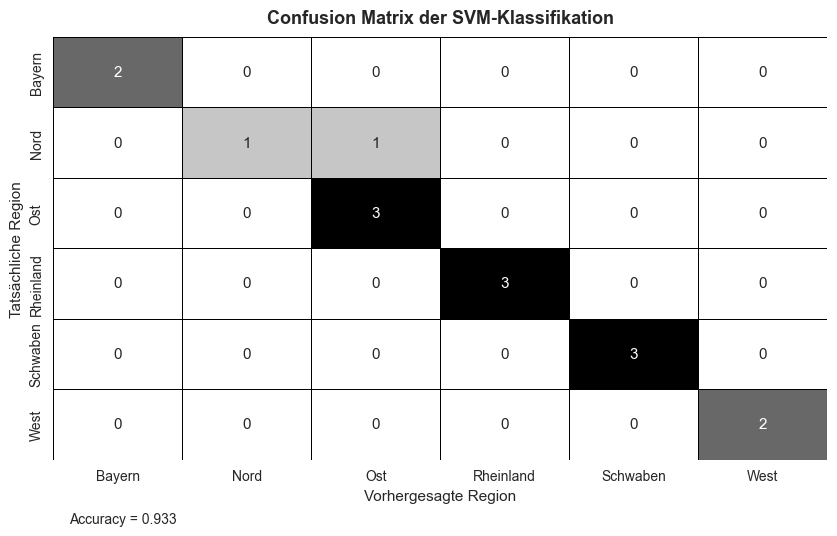

In [62]:
#Confusionmatrix

labels = ["Bayern", "Nord", "Ost", "Rheinland", "Schwaben", "West"]

cm = np.array([
    [2, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0, 0],
    [0, 0, 3, 0, 0, 0],
    [0, 0, 0, 3, 0, 0],
    [0, 0, 0, 0, 3, 0],
    [0, 0, 0, 0, 0, 2]
])


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
#    "xtick.labelsize": 9,
#    "ytick.labelsize": 10
})

sns.set_style("white")

fix, ax = plt.subplots(figsize = (8.5, 5.5))

sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    cmap = "Greys",
    cbar = False,
    xticklabels = labels,
    yticklabels = labels,
    linewidths = 0.5,
    linecolor = "black",
    ax = ax
)

ax.set_title("Confusion Matrix der SVM-Klassifikation", pad = 10, weight = "bold")
ax.set_xlabel("Vorhergesagte Region")
ax.set_ylabel("Tatsächliche Region")

accuracy = 0.9333
ax.text(
    0.02, -0.15,
    f"Accuracy = {accuracy:.3f}",
    transform = ax.transAxes,
    fontsize = 10
)

plt.tight_layout()
plt.savefig("ka9_confusion_matrix.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [32]:
#Kap 6.2
#Gini-Koeffizient

def gini(row):
    x = np.sort(row.values.astype(float))
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

gini_values = df_rel.apply(gini, axis = 1)

df_gini = gini_values.rename("Gini").reset_index()

if df_gini.columns[0] != "Ort":
    df_gini = df_gini.rename(columns = {df_gini.columns[0]: "Ort"})
    
df_gini.reset_index(drop = True)

df_gini = df_gini.merge(
    df_loc_region,
    on = "Ort",
    how = "left"
)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
#    "legend.fontsize": 9
})

fig, ax = plt.subplots(figsize = (6.3, 5.5))

sns.boxplot(
    data =df_gini,
    x = "Region",
    y = "Gini",
    color = "lightgrey",
    ax = ax
)

sns.stripplot(
    data =df_gini,
    x = "Region",
    y = "Gini",
    color = "black",
    size = 5,
    jitter = True,
    ax = ax
)

ax.set_title("Gini-Koeffizient der Namensverteilungen nach Region", pad = 10, weight = "bold")
ax.set_xlabel("Region")
ax.set_ylabel("Gini-Koeffizient")
ax.tick_params(axis = "x", rotation = 45)

plt.tight_layout()

plt.savefig(
    "kap6_gini_boxplot.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

NameError: name 'df_loc_region' is not defined

In [52]:
#Kap 5.2
#Variation von K

#Für Reproduzierbarkeit
SEED = 42
np.random.seed(SEED)

# Nachnamen definieren (häufigste Berufsnamen nach Nübling 2015, 154)

names = [
    "Müller", "Schmidt", "Schneider", "Fischer", "Meyer",
    "Weber", "Schulz", "Wagner", "Becker", "Zimmermann", 
    "Schäfer", "Koch", "Schröder", "Richter", "Bauer"
    
]

names2 = [
    "Hoffmann", "Krüger", "Keller", "Winkler", "Köhler",
    "Baumann", "Schuhmacher", "Schuster", "Jäger", "Kaufmann",
    "Schreiber", "Bergmann", "Krämer", "Ziegler", "Maurer"
]

names3 = [
    "Berger", "Pfeiffer", "Fiedler", "Förster", "Schütz",
    "Schindler", "Böttcher", "Gärtner", "Ackermann", "Geiger",
    "Fuhrmann", "Krieger", "Schreiner", "Fleischer", "Glaser"
]

name_sets = {
    15: names,
    30: names + names2,
    45: names + names2 + names3
}

# Regionen 

regions = [
    "Nord", "Rheinland", "Bayern",
    "West", "Schwaben", "Ost"
    
]

# Städte

cities ={

"Nord": [
    ("Hannover",52.37,9.72),
    ("Braunschweig",52.27,10.52),
    ("Bremen",53.08,8.80),
    ("Hamburg",53.55,10.00),
    ("Kiel",54.32,10.14),
    ("Lübeck",53.87,10.69),
    ("Rostock",54.09,12.14),
    ("Schwerin",53.63,11.41)    
],
    
"Ost":[
    ("Potsdam",52.39,13.06),
    ("Frankfurt (Oder)",52.35,14.55),
    ("Dresden",51.05,13.74),
    ("Leipzig",51.34,12.37),
    ("Magdeburg",52.13,11.63),
    ("Halle (Saale)",51.48,11.97),
    ("Erfurt",50.98,11.03),
    ("Berlin",52.52,13.40)
],
    
"West":[
    ("Köln",50.94,6.96),
    ("Münster", 51.96,7.63),
    ("Bonn",50.74,7.10),
    ("Gelsenkirchen",51.52,7.09),
    ("Frankfurt (Main)",50.11,8.68),
    ("Wiesbaden",50.08,8.24),
    ("Kassel",51.31,9.49),
    ("Marburg",50.81,8.77)
], 
    
"Rheinland":[
    ("Koblenz",50.36,7.60),
    ("Mainz",49.99,8.27),
    ("Trier",49.75,6.64),
    ("Cochem",50.15,7.17),
    ("Saarbrücken",49.23,7.00),
    ("Saarlouis",49.31,6.75),
    ("Weiskirchen",49.55,6.82),
    ("St. Ingbert",49.28,7.11)
],
    
"Bayern":[
    ("München",48.13,11.58),
    ("Nürnberg",49.45,11.08),
    ("Würzburg",49.79,9.95),
    ("Passau",48.57,13.46),
    ("Augsburg",48.37,10.90),
    ("Regensburg",49.02,12.10),
    ("Ingolstadt",48.76,11.42),
    ("Füssen",47.57,10.70),
],
    
"Schwaben":[
    ("Heidelberg",49.41,8.69),
    ("Mannheim",49.49,8.47),
    ("Stuttgart",48.78,9.18),
    ("Freiburg",47.99,7.85),
    ("Heilbronn",49.14,9.22),
    ("Tübingen",48.52,9.06),
    ("Konstanz",47.66,9.17),
    ("Ulm",48.40,10.00)
]

}

city_to_state = {
    "Hamburg": "Hamburg",
    "Kiel": "Schleswig-Holstein",
    "Lübeck": "Schleswig-Holstein",
    "Bremen": "Bremen",
    "Hannover": "Niedersachsen",
    "Braunschweig": "Niedersachsen",
    "Rostock": "Mecklenburg-Vorpommern",
    
    "Berlin": "Berlin",
    "Potsdam": "Brandenburg",
    "Frankfurt (Oder)": "Brandenburg",
    "Dresden": "Sachsen", 
    "Leipzig": "Sachsen",
    "Magdeburg": "Sachsen-Anhalt",
    "Halle (Saale)": "Sachsen-Anhalt",
    "Erfurt": "Thüringen",
    
    "Köln": "Nordrhein-Westfalen",
    "Münster": "Nordrhein-Westfalen", 
    "Bonn": "Nordrhein-Westfalen",
    "Gelsenkirchen": "Nordrhein-Westfalen",
    "Frankfurt (Main)": "Hessen",
    "Wiesbaden": "Hessen", 
    "Kassel": "Hessen",
    "Marburg": "Hessen",
    
    "Mainz": "Rheinland-Pfalz",
    "Trier": "Rheinland-Pfalz",
    "Koblenz": "Rheinland-Pfalz",
    "Cochem": "Rheinland-Pfalz",
    "Saarbrücken": "Saarland",
    "Saarlouis": "Saarland",
    "Weiskirchen": "Saarland",
    "St. Ingbert": "Saarland", 
    
    "München": "Bayern",
    "Nürnberg": "Bayern", 
    "Würzburg": "Bayern",
    "Passau": "Bayern",
    "Augsburg": "Bayern",
    "Regensburg": "Bayern",
    "Ingolstadt": "Bayern",
    "Füssen": "Bayern",
    
    "Stuttgart": "Baden-Württemberg",
    "Heidelberg": "Baden-Württemberg",
    "Mannheim": "Baden-Württemberg", 
    "Freiburg": "Baden-Württemberg", 
    "Heilbronn": "Baden-Württemberg",
    "Tübingen": "Baden-Württemberg", 
    "Konstanz": "Baden-Württemberg",
    "Ulm": "Baden-Württemberg"
}



#Dataframe erzeugen 

rows = []

for region,city_list in cities.items():
    
    for city,lat,lon in city_list:
        
        rows.append({
            "Region": region,
            "Ort": city,
            "lat": lat,
            "lon": lon
        })
        
df_locations = pd.DataFrame(rows)

df_locations["Bundesland"] = df_locations["Ort"].map(city_to_state)

# Nun Einwohnerzahl anhand lognormal-Verteilung generieren

np.random.seed(SEED)
df_locations["Einwohner"] = np.random.lognormal(
    mean = 9,
    sigma = 0.5,
    size = len(df_locations)
).astype(int)

df_locations["Einwohner"] = df_locations["Einwohner"].clip(5000,15000)
    
# Alpha-Werte für Makroregionen bestimmen 

region_alphas = {}

def build_region_alphas(names_current, dominance = 5.0, moderate = 2.0):
    
    freq_base = np.array([
        256003,
        190854,
        115749,
        97658,
        83586,
        86061,
        73736,
        79732,
        74009,
        42872,
        61591,
        59927,
        50648,
        59950,
        58903
    ], dtype = float)
    
    if len(names_current) > len(freq_base):
        extra = np.ones(len(names_current) - len(freq_base)) * np.mean(freq_base)
        freq = np.concatenate([freq_base, extra])
    else:
        freq = freq_base[:len(names_current)]
    
    alpha_base = freq / freq.max()
   
    
    alpha_national = alpha_base * 50 
    
    region_alphas = {}
    
    for r in regions:
        
        alpha = alpha_national.copy()
        
        def safe_boost(name, factor):
            if name in names_current:
                alpha[names_current.index(name)] *= factor
        
        if r == "Nord":
            alpha[names.index("Schröder")] *= dominance
            alpha[names.index("Schmidt")] *= moderate
            
        elif r == "Bayern":
            alpha[names.index("Bauer")] *= dominance
            alpha[names.index("Meyer")] *= moderate
            
        elif r == "Ost":
            alpha[names.index("Richter")] *= dominance
            alpha[names.index("Schulz")] *= moderate
            
        elif r == "Rheinland":
            alpha[names.index("Becker")] *= dominance
            alpha[names.index("Schäfer")] *= moderate
            
        elif r == "Schwaben":
            alpha[names.index("Zimmermann")] *= dominance
            alpha[names.index("Becker")] *= moderate
            
        elif r == "West":
            alpha[names.index("Schneider")] *= dominance
            alpha[names.index("Weber")] *= moderate
            
        region_alphas[r] = alpha
        
    return region_alphas

def simulate_micro_data(names_current, beta_value, seed = 42):
    
    np. random.seed(seed)
    
    region_alphas = build_region_alphas(names_current)
    
    rows = []
    
    for i,row in df_locations.iterrows():
    
        region = row["Region"]
        city = row["Ort"]
        state = row["Bundesland"]
        pop = row["Einwohner"]
    
        theta_region = np.random.dirichlet(region_alphas[region])    
        theta_city = np.random.dirichlet(beta_value * theta_region)

        persons = np.random.choice(
            names_current,
            size = pop,
            p = theta_city
        )
    
        for name in persons:

            rows.append([
                region,
                city,
                state,
                row["lat"],
                row["lon"],
                name
            ])
    
    df_micro_tmp = pd.DataFrame(
        rows,
        columns = ["Region", "Ort", "Bundesland", "lat", "lon", "Nachname"]
    )
    
    return df_micro_tmp

def micro_to_relative(df_micro_tmp):
    df_agg_tmp = (
        df_micro_tmp
        .groupby(["Ort", "Nachname"])
        .size()
        .unstack(fill_value = 0)
    )
    
    df_rel_tmp = df_agg_tmp.div(df_agg_tmp.sum(axis = 1), axis = 0)
    return df_rel_tmp

def compute_mean_js(df_rel_tmp, df_locations):
    
    df_region = (
        df_rel_tmp
        .merge(df_locations[["Ort", "Region"]], left_index = True, right_on = "Ort")
        .groupby("Region")
        .mean(numeric_only = True)
    )
    
    region_names = df_region.index.tolist()
    js_values = []
    
    for i in range(len(region_names)):
        for j in range(i + 1, len(region_names)):
            p = df_region.iloc[i].values
            q = df_region.iloc[j].values
            
            m = 0.5 * (p + q)
            
            def entropy(x):
                x = np.clip(x, 1e-12, 1)
                return -np.sum(x * np.log2(x))
            
            js = jensenshannon(p, q) ** 2
            js_values.append(js)
            
    return float(np.mean(js_values))
    

In [103]:
results_k = []
n_runs = 25

for K_value, names_current in name_sets.items():
    sil_values = []
    js_values = []
    
    for run in range(n_runs):
        seed = SEED + run
        
        df_micro_tmp = simulate_micro_data(
            names_current = names_current, 
            beta_value = 50, 
            seed = seed
        )
        
        df_rel_tmp = micro_to_relative(df_micro_tmp)
        
        kmeans = KMeans(
            n_clusters = 6,
            n_init = 50,
            random_state = SEED
        )
        
        labels = kmeans.fit_predict(df_rel_tmp)
        sil = silhouette_score(df_rel_tmp, labels)
        js_mean = compute_mean_js(df_rel_tmp, df_locations)
        
        sil_values.append(sil)
        js_values.append(js_mean)
        
    results_k.append({
        "K": K_value, 
        "mean_silhouette": np.mean(sil_values),
        "std_silhouette": np.std(sil_values),
        "mean_js_divergence": np.mean(js_values),
        "std_js_divergence": np.std(js_values),
        "n_valid_runs": 0
    })
    
    
df_k = pd.DataFrame(results_k)
print("\nErgebnisse Variation K:")
print(df_k.round(3))  


Ergebnisse Variation K:
    K  mean_silhouette  std_silhouette  mean_js_divergence  std_js_divergence  \
0  15            0.266           0.028               0.075              0.005   
1  30            0.109           0.019               0.055              0.005   
2  45            0.060           0.014               0.053              0.004   

   n_valid_runs  
0             0  
1             0  
2             0  


NameError: name 'df_k' is not defined

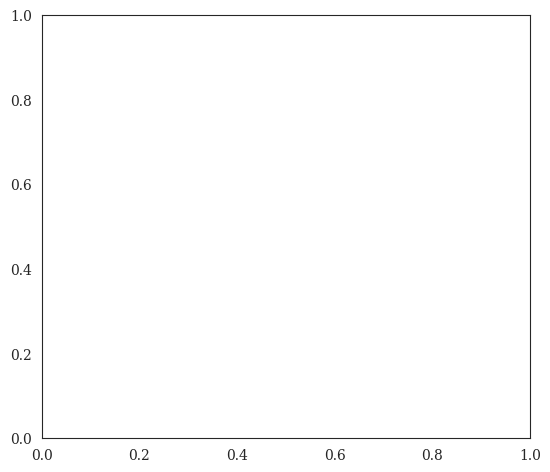

In [57]:
#Visualisierung von K

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
#    "legend.fontsize": 9
})

fig, ax1 = plt.subplots(figsize = (6.3, 5.5))

ax1.plot(
    df_k["K"],
    df_k["mean_silhouette"],
    marker = "o",
    linewidth = 1.5,
    label = "Silhouettenkoeffizient"
)

ax1.set_xlabel("Namendimension κ")
ax1.set_ylabel("Silhouettenkoeffizient")
ax1.set_title(
    "Einfluss der Namensdimension κ auf die Clusterqualität",
    pad = 10, 
    weight = "bold"
)

ax2 = ax1.twinx()

ax2.plot(
    df_k["K"],
    df_k["mean_js_divergence"],
    marker = "x",
    linestyle = "--",
    linewidth = 1.5,
    label = "JS-Divergenz"
)

ax2.set_ylabel("Jensen-Shannon-Divergenz")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

legend = ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2, 
    loc = "upper right", 
    frameon = True
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(0.6)

plt.tight_layout()

plt.savefig(
    "kap5_variation_kappa.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

In [53]:
# Kap. 5.3
#Variation von ß x K

beta_values = [20, 50, 100]
n_runs = 50

results_beta_kappa = []

for kappa_value, names_current in name_sets.items():
    for beta_value in beta_values:
        sil_values = []
        js_values = []
        
        print(f"\nStarte Kombination: β = {beta_value}, K = {kappa_value}")
    
        for run in range(n_runs):
            seed = SEED + run
        
            df_micro_tmp = simulate_micro_data(
                names_current = names_current, 
                beta_value = beta_value, 
                seed = seed
            )

            df_rel_tmp = micro_to_relative(df_micro_tmp)
            
            if df_rel_tmp.shape[0] < 6:
                print(f"Run {run}: übersprungen, nur {df_rel_tmp.shape[0]} Orte")
                continue
                
            
        
            kmeans = KMeans(
                n_clusters = 6,
                n_init = 50,
                random_state = SEED
            )
        
            labels = kmeans.fit_predict(df_rel_tmp)
            sil = silhouette_score(df_rel_tmp, labels)
            js_mean = compute_mean_js(df_rel_tmp, df_locations)
        
            sil_values.append(sil)
            js_values.append(js_mean)
            
        if len(sil_values) == 0:
            results_beta_kappa.append({
                "Beta": beta_value,
                "K": kappa_value, 
                "mean_silhouette": np.nan,
                "std_silhouette": np.nan,
                "mean_js_divergence": np.nan,
                "std_js_divergence": np.nan,
                "n_valid_runs": 0
            })
        else:
            results_beta_kappa.append({
                "Beta": beta_value,
                "K": kappa_value, 
                "mean_silhouette": np.mean(sil_values),
                "std_silhouette": np.std(sil_values),
                "mean_js_divergence": np.mean(js_values),
                "std_js_divergence": np.std(js_values),
                "n_valid_runs": len(sil_values)
            })
            
df_beta_kappa = pd.DataFrame(results_beta_kappa)
print("\nErgebnisse Interaktion Beta x Kappa:")
print(df_beta_kappa.round(3))
   


Starte Kombination: β = 20, K = 15

Starte Kombination: β = 50, K = 15

Starte Kombination: β = 100, K = 15

Starte Kombination: β = 20, K = 30

Starte Kombination: β = 50, K = 30

Starte Kombination: β = 100, K = 30

Starte Kombination: β = 20, K = 45

Starte Kombination: β = 50, K = 45

Starte Kombination: β = 100, K = 45

Ergebnisse Interaktion Beta x Kappa:
   Beta   K  mean_silhouette  std_silhouette  mean_js_divergence  \
0    20  15            0.175           0.019               0.085   
1    50  15            0.264           0.026               0.075   
2   100  15            0.356           0.029               0.068   
3    20  30            0.083           0.018               0.077   
4    50  30            0.111           0.015               0.054   
5   100  30            0.170           0.019               0.046   
6    20  45            0.057           0.010               0.087   
7    50  45            0.064           0.014               0.054   
8   100  45            

NameError: name 'ax1' is not defined

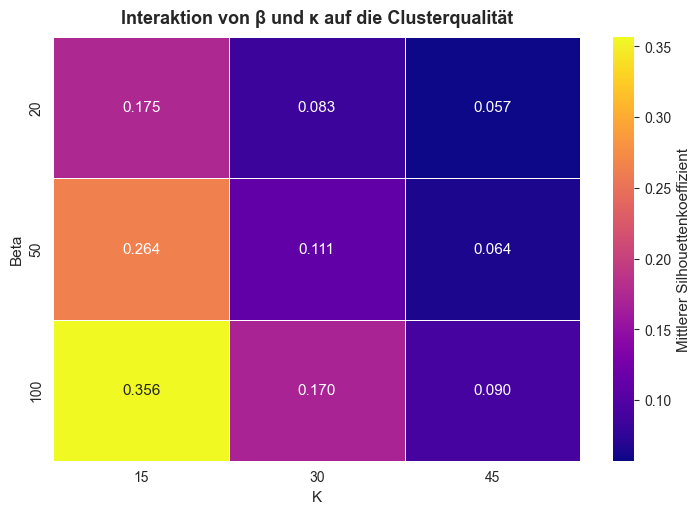

In [56]:
#Visualisierung

heatmap_sil = df_beta_kappa.pivot(
    index = "Beta",
    columns = "K",
    values = "mean_silhouette"
)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
#    "legend.fontsize": 9
})

sns.set_style("white")

fig, ax = plt.subplots(figsize = (8.5, 5.5))

sns.heatmap(
    heatmap_sil,
    annot = True,
    fmt = ".3f",
    cmap = "plasma",
    linewidths = 0.5,
    linecolor = "white",
    cbar_kws = {"label": "Mittlerer Silhouettenkoeffizient"},
    ax = ax
)

ax.set_title(
    "Interaktion von β und κ auf die Clusterqualität",
    pad = 10, 
    weight = "bold"
)
ax1.set_xlabel("Namendimension κ")
ax1.set_ylabel("Homogenitätsparameter β")


plt.tight_layout()
plt.savefig("kap5_heatmap_beta_kappa_silhouette.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [50]:
print(heatmap_sil)

NameError: name 'heatmap_sil' is not defined

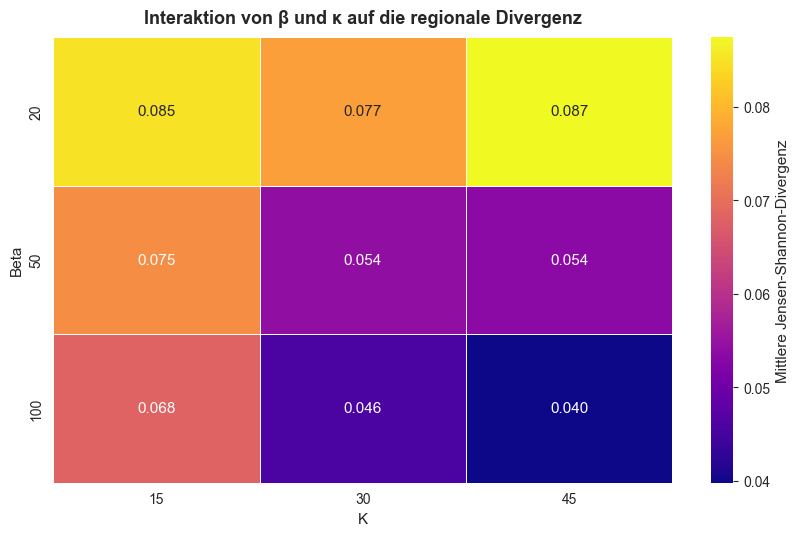

In [116]:
#Visualisierung 2

heatmap_js = df_beta_kappa.pivot(
    index = "Beta",
    columns = "K",
    values = "mean_js_divergence"
)

fig, ax = plt.subplots(figsize = (8.5, 5.5))

sns.heatmap(
    heatmap_js,
    annot = True,
    fmt = ".3f",
    cmap = "plasma",
    linewidths = 0.5,
    linecolor = "white",
    cbar_kws = {"label": "Mittlere Jensen-Shannon-Divergenz"},
    ax = ax
)

ax.set_title(
    "Interaktion von β und κ auf die regionale Divergenz",
    pad = 10, 
    weight = "bold"
)
ax1.set_xlabel("Namendimension κ")
ax1.set_ylabel("Homogenitätsparameter β")


plt.tight_layout()
plt.savefig("kap5_heatmap_beta_kappa_js.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [31]:
print(df_gini)

NameError: name 'df_gini' is not defined

In [37]:
#Kap 6.2
#Hardcodieren, weil keinen Seed gesetzt

data = [
    ("Augsburg", 0.532311, "Bayern"),
    ("Berlin", 0.410550, "Ost"),
    ("Bonn", 0.594144, "West"),
    ("Braunschweig", 0.558356, "Nord"),
    ("Bremen", 0.502253, "Nord"),
    ("Cochem", 0.514227, "Rheinland"),
    ("Dresden", 0.430040, "Ost"),
    ("Erfurt", 0.472880, "Ost"),
    ("Frankfurt (Main)", 0.513858, "West"),
    ("Frankfurt (Oder)", 0.473717, "Ost"), 
    ("Freiburg", 0.419225, "Schwaben"), 
    ("Füssen", 0.341319, "Bayern"), 
    ("Gelsenkirchen", 0.560667, "West"), 
    ("Halle (Saale)", 0.457333, "Ost"), 
    ("Hamburg", 0.551324, "Nord"), 
    ("Hannover", 0.560136, "Nord"), 
    ("Heidelberg", 0.322584, "Schwaben"), 
    ("Heilbronn", 0.446480, "Schwaben"), 
    ("Ingolstadt", 0.406720, "Bayern"), 
    ("Kassel", 0.507481, "West"), 
    ("Kiel", 0.476426, "Nord"), 
    ("Koblenz", 0.480212, "Rheinland"), 
    ("Konstanz", 0.327843, "Schwaben"), 
    ("Köln", 0.536293, "West"), 
    ("Leipzig", 0.480096, "Ost"), 
    ("Lübeck", 0.422219, "Nord"),  
    ("Magdeburg", 0.534689, "Ost"), 
    ("Mainz", 0.490555, "Rheinland"), 
    ("Mannheim", 0.434904, "Schwaben"), 
    ("Marburg", 0.583893, "West"), 
    ("München", 0.455683, "Bayern"), 
    ("Münster", 0.552389, "West"), 
    ("Nürnberg", 0.452427, "Bayern"), 
    ("Passau", 0.427573, "Bayern"), 
    ("Potsdam", 0.393840, "Ost"), 
    ("Regensburg", 0.402347, "Bayern"), 
    ("Rostock", 0.576702, "Nord"), 
    ("Saarbrücken", 0.449067, "Rheinland"), 
    ("Saarlouis", 0.455214, "Rheinland"), 
    ("Schwerin", 0.501752, "Nord"), 
    ("St. Ingbert", 0.417538, "Rheinland"), 
    ("Stuttgart", 0.395711, "Schwaben"), 
    ("Trier", 0.453627, "Rheinland"), 
    ("Tübingen", 0.373654, "Schwaben"), 
    ("Ulm", 0.396236, "Schwaben"), 
    ("Weiskirchen", 0.452671, "Rheinland"), 
    ("Wiesbaden", 0.551828, "West"), 
    ("Würzburg", 0.466094, "Bayern")    
]

df_gini = pd.DataFrame(data, columns = ["Ort", "Gini", "Region"])

print(df_gini.head())
print(df_gini.shape)

df_gini.to_csv("gini_orte.csv", index = False)

            Ort      Gini  Region
0      Augsburg  0.532311  Bayern
1        Berlin  0.410550     Ost
2          Bonn  0.594144    West
3  Braunschweig  0.558356    Nord
4        Bremen  0.502253    Nord
(48, 3)


Absolute Häufigkeiten pro Region:
Nachname  Bauer  Becker  Fischer  Koch  Meyer  Müller  Richter  Schmidt  \
Region                                                                    
Nord       3478    3071     3881  2134   4688   14479     2017    21535   
Ost        1698    2275     2526  1705   2806    6816     9577     5798   
West       2250    1898     3023  1322   1783    5849     1589     6023   
Bayern     8150    3351     2222  2231   9333    6253     1362     4929   
Schwaben   2214    8998     4030  1409   3249    6175     2507     8159   

Nachname  Schneider  Schröder  Schulz  Schäfer  Wagner  Weber  Zimmermann  
Region                                                                     
Nord           4903      9595    2196     3488    3785   4167        2039  
Ost            2818      1779    7323     1660    1805   4671        1886  
West          17306      2329    3849     1602    3756   6966         701  
Bayern         4848      1243    1785     3623    4519   351

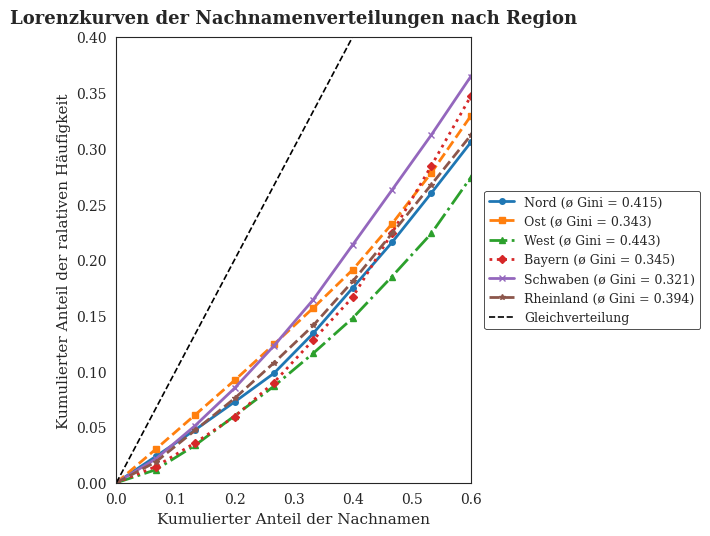

In [47]:
#Visualisierung verschiedener Ginoi-Koeffizienten 

region_order = ["Nord", "Ost", "West", "Bayern", "Schwaben", "Rheinland"]

df_region_abs = pd.crosstab(
    df_micro["Region"],
    df_micro["Nachname"]
)

df_region_abs = df_region_abs.loc[region_order]

print("Absolute Häufigkeiten pro Region:")
print(df_region_abs.head())

df_region_rel = df_region_abs.div(df_region_abs.sum(axis = 1), axis = 0)

print("\nRelative Nachnamenverteilungen pro Region:")
print (df_region_rel.round(4))

def gini_from_distribution(values):
    x = np.array(values, dtype = float)
    x = np.sort(x)
    
    if np.sum(x) == 0:
        return np.nan
    
    n = len(x)
    cumx = np.cumsum(x)
    
    gini = (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n
    return gini 

df_gini_region = pd.DataFrame({
    "Region": region_order,
    "Gini": [gini_from_distribution(df_region_rel.loc[r].values) for r in region_order]
})

print("\nGini-Koeffizienten auf Regionsebene:")
print(df_gini_region.round(3))

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9
})

fig, ax = plt.subplots(figsize = (6.8, 5.5))

linestyles = ["-", "--", "-.", ":", "-", "--"]
markers = ["o", "s", "^", "D", "x", "*"]

for i, region in enumerate(region_order):
    values = df_region_rel.loc[region].values
    
    values = np.sort(values)
    
    values = values / values.sum()
    
    cum_values = np.cumsum(values)
    
    lorenz_y = np.insert(cum_values, 0, 0)
    lorenz_x = np.linspace(0, 1, len(lorenz_y))
    
    gini_val = gini_from_distribution(df_region_rel.loc[region].values)
    
    ax.plot(
        lorenz_x,
        lorenz_y,
        linewidth = 2,
        linestyle = linestyles[i],
        marker = markers[i],
        markersize = 4, 
        markevery = max(1, len(lorenz_x)//10),
        label = f"{region} (ø Gini = {gini_val:.3f})"
    )
    
ax.plot(
    [0, 1],
    [0, 1],
    linestyle = "--",
    linewidth = 1.2,
    color = "black",
    label = "Gleichverteilung"
)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

ax.set_title("Lorenzkurven der Nachnamenverteilungen nach Region", pad = 10, weight = "bold")
ax.set_xlabel("Kumulierter Anteil der Nachnamen")
ax.set_ylabel("Kumulierter Anteil der ralativen Häufigkeit")

legend = ax.legend(
    loc = "center left",
    bbox_to_anchor = (1.02, 0.5),
    frameon = True
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(0.6)

plt.tight_layout()

plt.savefig(
    "kap6_lorenzkurven_regionale_nachnamenverteilungen.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()